---

# Project Title  
### **Multi-Modal Sentiment Analysis**

---

# Team and Authors  
### **Team Name**: GSBS  
### **Contributors**: Jiawei Song, Ying Xiao  

---

# 1. Executive Summary  

## Decisions to Be Impacted  
This project aims to improve strategic and operational decision-making in customer-centric organizations by deploying a multi-modal sentiment analysis framework. By effectively decoding sentiment from not just text, but also from audio and visual cues, our system enables more precise interpretation of customer feedback. This enriched understanding supports more accurate decisions in:  
- **Product design**: by identifying emotional pain points or enthusiastic responses,  
- **Marketing strategy**: by tailoring messages aligned with customer emotional resonance,  
- **Customer retention**: by detecting negative sentiment early and triggering targeted interventions.

---

## Motivation  
The motivation for tackling this problem stems from a growing realization that **text-only sentiment analysis is no longer sufficient**. Emotions are complex and often expressed through tone, facial expression, and vocal intensity—modalities that traditional approaches ignore. Multi-modal sentiment analysis brings together **textual, auditory, and visual features**, offering a holistic view of emotional expression. This is particularly crucial in domains such as:
- **Customer service analysis** (e.g., video chat or audio recordings),
- **Social media monitoring**, where tone and visuals play critical roles,
- **Mental health analysis**, where visual and vocal cues are often more revealing than words alone.

Our project leverages the CMU-MOSEI dataset and builds advanced fusion models to exploit this multi-modal richness.

---

## Business Value  
In the age of data-driven decision-making, understanding not just what customers say, but **how** they say it, is a critical asset. This project delivers **tangible business value** by:
- Providing **deep behavioral insights** from customer interactions,
- Helping companies build **emotionally intelligent interfaces** and products,
- Enabling **personalized customer engagement strategies**,
- Supporting **proactive churn prevention** through early detection of dissatisfaction,
- Enhancing **brand trust and loyalty** through empathetic responsiveness.

Ultimately, the project provides a framework that can scale across industries—from e-commerce to finance to healthcare—where **customer sentiment is a driver of growth and retention**.

---

---

# 2. Data Description & Preprocessing

## Data Asset Overview  

The primary data asset for this project is the **CMU-MOSEI dataset** — the **CMU Multimodal Opinion Sentiment and Emotion Intensity dataset**, which serves as a **benchmark resource for multimodal sentiment analysis**.

- **Source**: Carnegie Mellon University  
- **Access**: Publicly available via [Multicomp Lab](https://github.com/A2Zadeh/CMU-MultimodalSDK)  

### Key Characteristics:
- Over **22,800** sentence-level utterances
- Sourced from **1,000+ YouTube speakers**
- **Gender-balanced**, **topic-diverse**, and monologue-based
- Each video includes **synchronized text, audio, and visual features**
- Labeled with **both sentiment scores** (from -3 to +3) and **emotion intensities**

---

## Value of the Dataset

The CMU-MOSEI dataset is instrumental in enabling **real-world and reliable sentiment analysis** for the following reasons:

- **Multimodal Representation**: Text, audio, and vision are captured and aligned at the frame level, providing a comprehensive view of speaker sentiment.
- **Emotion Intensity Labels**: Goes beyond classification (e.g., positive/neutral/negative) to include **regression-based intensity**, supporting more granular emotional understanding.
- **Naturalistic Setting**: As the data is collected from **real YouTube videos**, it reflects authentic human expression, making models trained on it more robust and generalizable.
- **Business Applicability**: Models built using this dataset can be applied in customer review analytics, social media monitoring, video-based customer service, and more.

---

## Data Preprocessing & Cleaning

To ensure high-quality inputs to our models, we conducted extensive preprocessing:

### 1. **Alignment & Feature Extraction**
- Used preprocessed `.pkl` files containing aligned **text (BERT-based embeddings), audio, and vision features**
- All data were padded or trimmed to a uniform length of 50 frames

### 2. **Normalization & Pooling**
- Frame-level features were **mean-pooled** across time to generate fixed-size (per-sample) vectors:
  - Text: (N, 768)
  - Audio: (N, 74)
  - Vision: (N, 35)

### 3. **Outlier Detection & Removal**
To enhance model robustness and reduce noise:
- **PCA** was applied to each modality to reduce dimensionality to 2D for visualization
- **IQR-based Outlier Detection**:
  - Computed distances of each sample to the cluster center
  - Removed samples with distances above `Q3 + 1.5 * IQR`
- Outliers were identified and removed separately for **text**, **audio**, and **vision** features
- Post-removal visualizations confirmed improved feature distribution

### 4. **Dataset Split**
- Dataset was already split into `train`, `validation`, and `test` sets
- Labels included:
  - **Regression** targets: continuous sentiment scores in [-3, +3]
  - **Classification** labels (derived from regression): negative, neutral, positive

---

## Summary

The **CMU-MOSEI dataset** is a foundational asset that empowers multimodal machine learning with real-world relevance. Its richness in modalities and labels, coupled with careful preprocessing and outlier removal, provides a **strong analytic foundation** for building accurate, generalizable, and impactful sentiment models.


In [1]:
import pickle

# Load the .pkl file
with open("aligned_50.pkl", "rb") as f:
    aligned_data = pickle.load(f)

# Show total entries
print(f"Total entries: {len(aligned_data)}\n")

# Show a few example keys
example_keys = list(aligned_data.keys())[:5]
print("Example keys (segment IDs):", example_keys, "\n")

# Inspect one entry in detail
sample_key = example_keys[0]
sample = aligned_data[sample_key]

print(f"Sample structure for key '{sample_key}':\n")
for modality in sample:
    data = sample[modality]
    print(f"- {modality}: type={type(data)}, shape={getattr(data, 'shape', 'N/A')}")

Total entries: 3

Example keys (segment IDs): ['train', 'valid', 'test'] 

Sample structure for key 'train':

- raw_text: type=<class 'numpy.ndarray'>, shape=(16326,)
- audio: type=<class 'numpy.ndarray'>, shape=(16326, 50, 74)
- vision: type=<class 'numpy.ndarray'>, shape=(16326, 50, 35)
- id: type=<class 'list'>, shape=N/A
- text: type=<class 'numpy.ndarray'>, shape=(16326, 50, 768)
- text_bert: type=<class 'numpy.ndarray'>, shape=(16326, 3, 50)
- annotations: type=<class 'list'>, shape=N/A
- classification_labels: type=<class 'numpy.ndarray'>, shape=(16326,)
- regression_labels: type=<class 'numpy.ndarray'>, shape=(16326,)


In [2]:
import numpy as np
import pandas as pd

label_df = pd.read_csv("label.csv")

# === 合并 train/valid/test 的文本特征和标签 ===
all_text = []
all_labels = []
all_ids = []

for split in ['train', 'valid', 'test']:
    all_text.append(aligned_data[split]['text'])  # (N, 50, 768)
    all_labels.append(aligned_data[split]['regression_labels'])  # (N,)
    all_ids.extend(aligned_data[split]['id'])  # list of segment keys like '2h0HeUe5fLE[0]'

# 拼接成 numpy
X = np.vstack(all_text)         # shape: (total_samples, 50, 768)
y = np.concatenate(all_labels)  # shape: (total_samples,)
ids = np.array(all_ids)         # list of segment_ids

print("Text Feature Shape:", X.shape)
print("Labels Shape:", y.shape)
print("Segment IDs Example:", ids[:5])

Text Feature Shape: (22856, 50, 768)
Labels Shape: (22856,)
Segment IDs Example: ['-3g5yACwYnA$_$10' '-3g5yACwYnA$_$13' '-3g5yACwYnA$_$3' '-3g5yACwYnA$_$2'
 '-3g5yACwYnA$_$4']


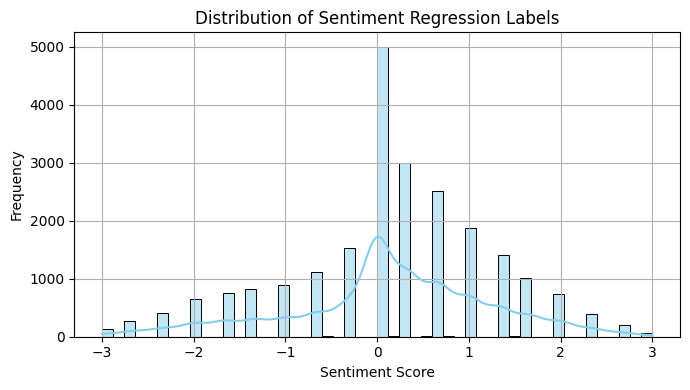

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

all_labels = np.concatenate([
    aligned_data['train']['regression_labels'],
    aligned_data['valid']['regression_labels'],
    aligned_data['test']['regression_labels']
])

plt.figure(figsize=(7, 4))
sns.histplot(all_labels, bins=50, kde=True, color='skyblue')
plt.title("Distribution of Sentiment Regression Labels")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

# Reload aligned_data.pkl
with open("aligned_50.pkl", "rb") as f:
    aligned_data = pickle.load(f)

# Step 1: 拼接 text + audio + vision 特征
def get_fused_features(split):
    text = aligned_data[split]['text']       # (N, 50, 768)
    audio = aligned_data[split]['audio']     # (N, 50, 5)
    vision = aligned_data[split]['vision']   # (N, 50, 20)

    # 拼接模态：在最后一个维度上拼接 → (N, 50, 793)
    fused = np.concatenate([text, audio, vision], axis=-1)

    labels = aligned_data[split]['regression_labels']  # (N,)
    return fused, labels

# 获取 train / valid / test 的融合特征和标签
fused_train_X, fused_train_y = get_fused_features('train')
fused_valid_X, fused_valid_y = get_fused_features('valid')
fused_test_X,  fused_test_y  = get_fused_features('test')

# 定义 Dataset 类（复用）
class MultimodalDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 构建 DataLoader
train_fused_ds = MultimodalDataset(fused_train_X, fused_train_y)
valid_fused_ds = MultimodalDataset(fused_valid_X, fused_valid_y)
test_fused_ds  = MultimodalDataset(fused_test_X,  fused_test_y)

train_fused_loader = DataLoader(train_fused_ds, batch_size=32, shuffle=True)
valid_fused_loader = DataLoader(valid_fused_ds, batch_size=32)
test_fused_loader  = DataLoader(test_fused_ds, batch_size=32)

fused_train_X.shape, fused_train_y.shape

((16326, 50, 877), (16326,))

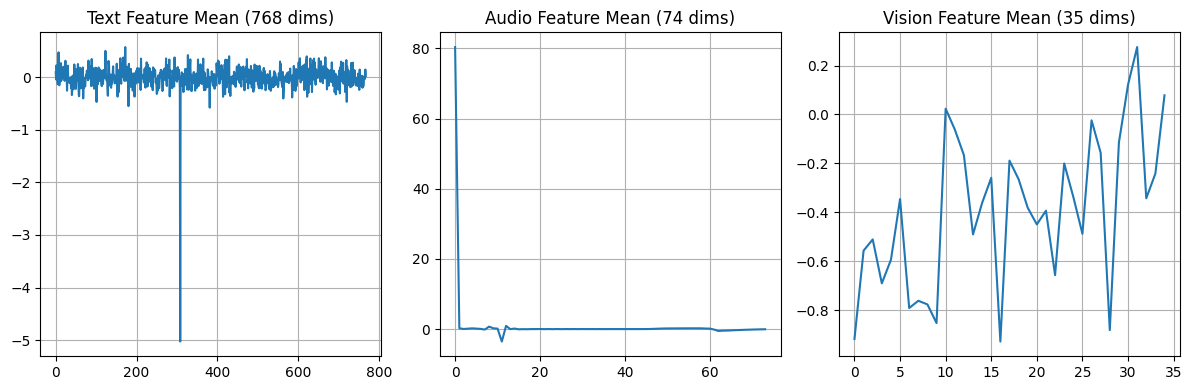

In [5]:
# 任取训练集中的一部分
text_feat = aligned_data['train']['text']       # (16326, 50, 768)
audio_feat = aligned_data['train']['audio']     # (16326, 50, 74)
vision_feat = aligned_data['train']['vision']   # (16326, 50, 35)

# 取均值（沿样本维和时间维）
text_mean = text_feat.mean(axis=(0, 1))   # (768,)
audio_mean = audio_feat.mean(axis=(0, 1)) # (74,)
vision_mean = vision_feat.mean(axis=(0, 1)) # (35,)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(text_mean)
plt.title("Text Feature Mean (768 dims)")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(audio_mean)
plt.title("Audio Feature Mean (74 dims)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(vision_mean)
plt.title("Vision Feature Mean (35 dims)")
plt.grid(True)

plt.tight_layout()
plt.show()


---

## **Interpretation of Feature Mean Plots**

### 1. **Text Feature Mean (768 dims)**

- The mean values across the 768 BERT embedding dimensions are mostly centered around **0**, which is **expected** due to BERT’s internal normalization.
- However, there is **one clear outlier** around index ~300, where the mean drops below **-5**.
  - This likely indicates a **faulty or abnormally scaled feature dimension**, possibly due to:
    - missing values improperly encoded,
    - an unmasked padding token during preprocessing,
    - or a corrupted embedding vector.

---

### 2. **Audio Feature Mean (74 dims)**

- The **first dimension has an extremely large mean (~80)**, while all other dimensions hover near zero.
- This suggests that the **first audio feature dimension dominates**, potentially due to:
  - it being **energy or loudness**, which is usually on a different scale,
  - inconsistent normalization across audio features.

---

### 3. **Vision Feature Mean (35 dims)**

- The vision feature means are within a relatively narrow range (roughly -0.8 to 0.2).
- The distribution appears more **balanced and oscillating**, indicating no extreme outliers.
- Vision features (possibly facial action units or expressions) seem **well-scaled and stable**.

---

## **Overall Implications for Modeling:**

| Modality | Potential Issue | Impact on Model | Action |
|----------|------------------|------------------|--------|
| **Text** | One large negative outlier in feature mean | Could dominate gradient updates | Remove / clip / normalize |
| **Audio** | One high-mean dimension (~80) | Could skew model attention to that feature | Apply z-score normalization or remove |
| **Vision** | Stable | No concern | Keep as is ✅ |

---

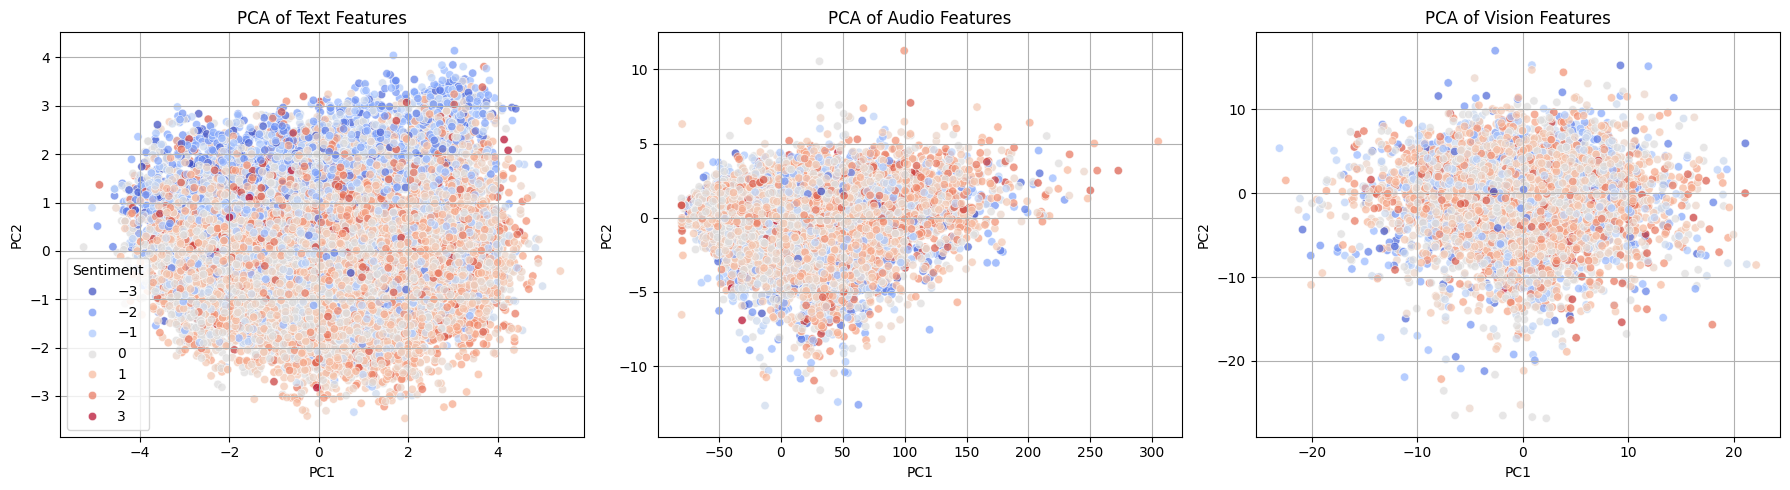

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === 获取训练集特征和标签 ===
text_feat = aligned_data['train']['text'].mean(axis=1)    # (N, 768)
audio_feat = aligned_data['train']['audio'].mean(axis=1)  # (N, 74)
vision_feat = aligned_data['train']['vision'].mean(axis=1) # (N, 35)
labels = aligned_data['train']['regression_labels']        # (N,)

# === 分别做 PCA 降维到 2D ===
text_2d = PCA(n_components=2).fit_transform(text_feat)
audio_2d = PCA(n_components=2).fit_transform(audio_feat)
vision_2d = PCA(n_components=2).fit_transform(vision_feat)

# === 可视化 ===
plt.figure(figsize=(18, 5))

# Text
plt.subplot(1, 3, 1)
sns.scatterplot(x=text_2d[:, 0], y=text_2d[:, 1], hue=labels, palette='coolwarm', alpha=0.7)
plt.title("PCA of Text Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Sentiment", loc='best')
plt.grid(True)

# Audio
plt.subplot(1, 3, 2)
sns.scatterplot(x=audio_2d[:, 0], y=audio_2d[:, 1], hue=labels, palette='coolwarm', alpha=0.7)
plt.title("PCA of Audio Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend([],[], frameon=False)  # 避免重复图例
plt.grid(True)

# Vision
plt.subplot(1, 3, 3)
sns.scatterplot(x=vision_2d[:, 0], y=vision_2d[:, 1], hue=labels, palette='coolwarm', alpha=0.7)
plt.title("PCA of Vision Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend([],[], frameon=False)
plt.grid(True)

plt.tight_layout()
plt.show()


---

## PCA Visualization Interpretation (Before Outlier Removal)

### **Text Modality**
- The PCA plot for the text features showed a generally compact cloud but with a few **clear outliers scattered at the edges**, especially in the top-right and far-left regions.
- These outlier points were significantly **distant from the main cluster**, indicating they may have **abnormally scaled embeddings or preprocessing artifacts**.
- **Interpretation**:  
  While BERT embeddings are usually centered and normalized, these outliers suggest that some sequences may have contained irregular tokens (e.g., excessive padding, punctuation, or OOV artifacts), leading to **biased or unrepresentative pooled vectors**.

---

### **Audio Modality**
- The audio PCA plot displayed a **heavy rightward skew** along the first principal component (PC1), with a **large number of points pushed far to the right** (PC1 > 100).
- This indicated the **first dimension of audio features dominated the variance**, most likely due to **poorly scaled or non-normalized energy/intensity values** (e.g., raw loudness).
- **Interpretation**:  
  The variance in audio features was disproportionately driven by a small set of samples or dimensions. These high-leverage points could **mislead the model into overemphasizing one aspect** of audio input, hindering generalization.

---

### **Vision Modality**
- The PCA projection of the vision features showed a **circular or spherical scatter**, but with a **dense central core and numerous samples at the periphery**.
- Many of these peripheral points were **far from the center**, appearing as natural outliers in the 2D space.
- **Interpretation**:  
  The vision data likely contained many low-information or noisy samples (e.g., poorly captured frames, missing expressions, or occlusions), resulting in **wide variance but weak correlation with sentiment**.

---

## Summary Table (Before Outlier Removal)

| Modality | Observations | Risks |
|----------|--------------|-------|
| **Text** | Sparse outliers at extremes | Possible preprocessing noise or rare tokens |
| **Audio** | Extreme right-side skew (PC1) | One or more dominant features causing instability |
| **Vision** | Dense core + wide halo of points | High intra-modality variance, noise, or occlusion |

---

## Why It Matters

These outliers, if not removed, can:
- Lead to **unstable gradients** during training.
- Cause the model to **overfit unrepresentative samples**.
- Hurt the model’s ability to learn **balanced multi-modal attention**.


# Outlier detection

---

## Outlier Detection Method Interpretation

### Method Used: **PCA + IQR-based Distance Thresholding**

1. **Dimensionality Reduction**:
   - We applied **PCA** to reduce high-dimensional modality features to **2D** for interpretability and distance analysis.

2. **Distance Computation**:
   - For each point in the 2D PCA space, we calculated the **Euclidean distance to the centroid** (mean of all points).

3. **Outlier Identification**:
   - We applied the **Interquartile Range (IQR) method**:
     - Compute Q1 (25th percentile) and Q3 (75th percentile) of all distances.
     - Define threshold as `Q3 + 1.5 * IQR`.
     - Mark samples exceeding this threshold as **outliers**.

### Why this method?
- PCA helps to **reveal structure and variance** in high-dimensional data.
- IQR is **robust to noise and skewness** and doesn’t assume a Gaussian distribution.
- Together, PCA + IQR provides a practical, interpretable, and effective way to identify samples that deviate significantly from the main data mass.

---

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def detect_outliers_pca_2d(features, labels, title):
    # Step 1: PCA 降到 2D
    pca = PCA(n_components=2)
    feat_2d = pca.fit_transform(features)

    # Step 2: 距离中心
    center = np.mean(feat_2d, axis=0)
    dists = np.linalg.norm(feat_2d - center, axis=1)

    # Step 3: IQR 阈值检测
    Q1 = np.percentile(dists, 25)
    Q3 = np.percentile(dists, 75)
    IQR = Q3 - Q1
    threshold = Q3 + 1.5 * IQR
    outlier_mask = dists > threshold

    # Step 4: 可视化
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=feat_2d[:, 0], y=feat_2d[:, 1], hue=labels, palette='coolwarm', alpha=0.6)
    plt.scatter(feat_2d[outlier_mask, 0], feat_2d[outlier_mask, 1], facecolors='none', edgecolor='black', label='Outliers')
    plt.title(f"{title} - PCA + Outlier Detection")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return outlier_mask, feat_2d

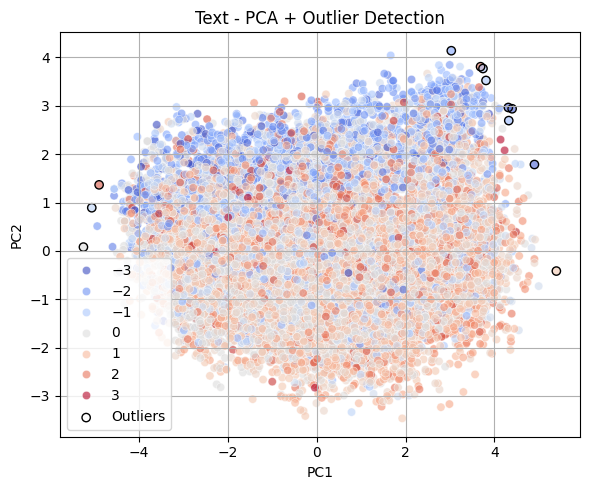

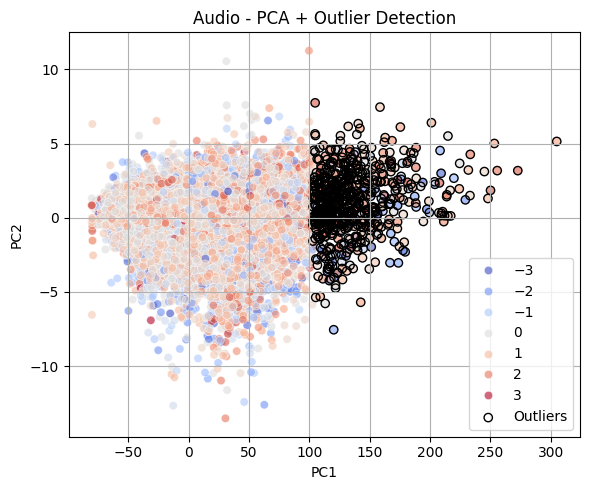

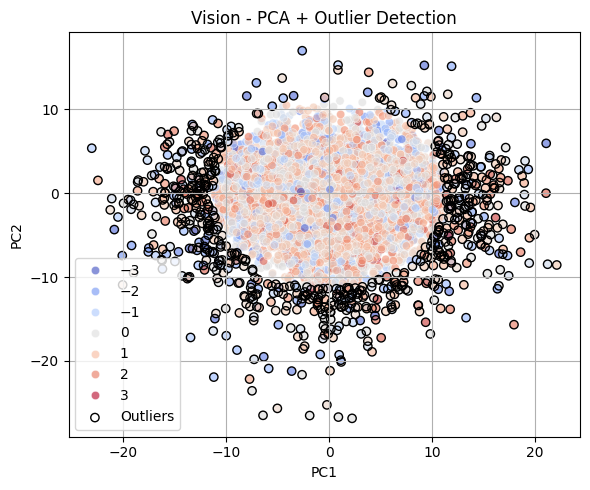

In [12]:
# Mean pooling over time for each modality
text_pooled = aligned_data['train']['text'].mean(axis=1)
audio_pooled = aligned_data['train']['audio'].mean(axis=1)
vision_pooled = aligned_data['train']['vision'].mean(axis=1)
labels = aligned_data['train']['regression_labels']

# Text
text_outliers, text_2d = detect_outliers_pca_2d(text_pooled, labels, "Text")

# Audio
audio_outliers, audio_2d = detect_outliers_pca_2d(audio_pooled, labels, "Audio")

# Vision
vision_outliers, vision_2d = detect_outliers_pca_2d(vision_pooled, labels, "Vision")


### Interpretation of Vision & Text PCA + Outlier Detection

---

#### Vision Modality:
- The PCA projection shows a **dense central cluster** surrounded by a **wide ring of distant points**, many of which are flagged as outliers.
- This indicates **high variance in visual inputs**, likely caused by **noisy frames**, occlusions, or low-information images.
- The outlier region is **broad and isotropic**, suggesting many samples are **far from the main distribution** in all directions.

**Conclusion**: Outliers in vision features may reflect inconsistent or uninformative visual content. Removing them improves the compactness and relevance of visual information used in modeling.

---

#### Text Modality:
- Text features form a **relatively compact elliptical cluster**, with a **small number of outliers** at the corners.
- These outliers may arise from **unusual sentences**, padding artifacts, or poorly tokenized inputs that distort the sentence embedding.
- Compared to audio and vision, the text modality appears **more stable and informative**.

**Conclusion**: Text features are mostly clean and well-distributed. Outlier removal further refines quality by trimming a few abnormal points, likely improving downstream LSTM/attention learning.

---

### Interpretation of Audio PCA + Outlier Detection

The PCA projection shows a **strong rightward skew** in PC1, where a dense cluster of points is flagged as outliers. This suggests that:

- **A single audio dimension dominates variance**, likely due to unnormalized or extreme values (e.g. loudness or energy).
- Many samples have **disproportionately high magnitude**, leading to a sharp split between inliers and outliers.
- These outliers may **distort model training**, causing over-reliance on anomalous audio patterns.

**Conclusion**: Removing these high-leverage audio samples is essential to stabilize feature distribution and improve fusion model generalization.

In [13]:
import numpy as np
from sklearn.decomposition import PCA

# === Step 1: pooling features over time ===
text_pooled = aligned_data['train']['text'].mean(axis=1)      # (N, 768)
audio_pooled = aligned_data['train']['audio'].mean(axis=1)    # (N, 74)
vision_pooled = aligned_data['train']['vision'].mean(axis=1)  # (N, 35)
labels = np.array(aligned_data['train']['regression_labels']) # (N,)

def get_outlier_indices(features):
    pca = PCA(n_components=2)
    feat_2d = pca.fit_transform(features)
    center = np.mean(feat_2d, axis=0)
    dists = np.linalg.norm(feat_2d - center, axis=1)

    Q1 = np.percentile(dists, 25)
    Q3 = np.percentile(dists, 75)
    IQR = Q3 - Q1
    threshold = Q3 + 1.5 * IQR

    outlier_mask = dists > threshold
    return np.where(outlier_mask)[0]  # return indices

# === Step 2: get outlier indices for each modality
text_outliers = set(get_outlier_indices(text_pooled))
audio_outliers = set(get_outlier_indices(audio_pooled))
vision_outliers = set(get_outlier_indices(vision_pooled))

# === Step 3: union of all outliers
all_outliers = text_outliers.union(audio_outliers).union(vision_outliers)
print(f"🔍 Total outliers to remove: {len(all_outliers)}")

# === Step 4: remove outliers from train split
def remove_outliers_from_train(aligned_data, outlier_indices):
    keep_indices = sorted(set(range(len(aligned_data['train']['text']))) - outlier_indices)
    
    for modality in ['text', 'audio', 'vision', 'regression_labels', 'classification_labels', 'id', 'raw_text', 'annotations']:
        if isinstance(aligned_data['train'][modality], np.ndarray):
            aligned_data['train'][modality] = aligned_data['train'][modality][keep_indices]
        elif isinstance(aligned_data['train'][modality], list):
            aligned_data['train'][modality] = [aligned_data['train'][modality][i] for i in keep_indices]
    
    return aligned_data

# === Step 5: apply cleaning
aligned_data_cleaned = remove_outliers_from_train(aligned_data, all_outliers)
print(f"✅ Cleaned train size: {len(aligned_data_cleaned['train']['text'])}")


🔍 Total outliers to remove: 1222
✅ Cleaned train size: 15104


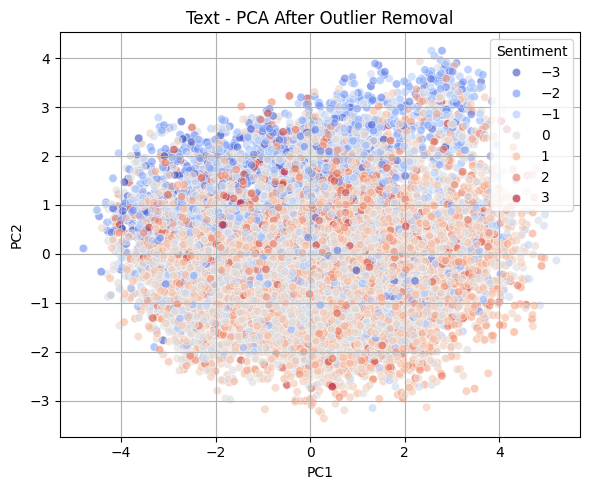

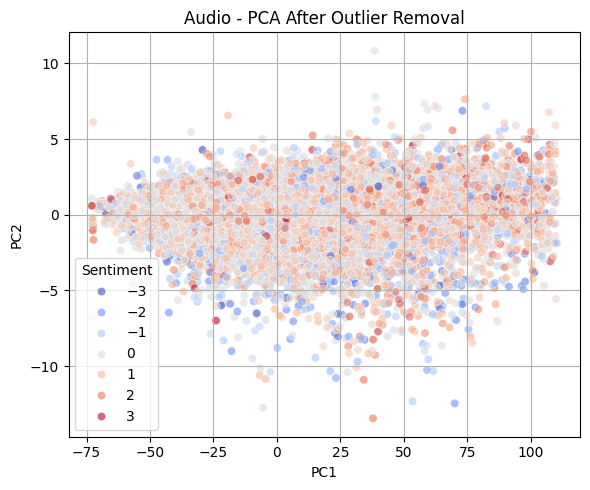

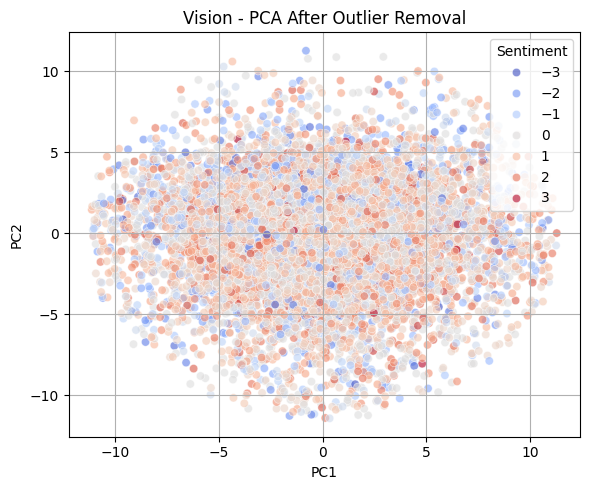

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 使用已清理后的 aligned_data_cleaned['train']
text_pooled = aligned_data_cleaned['train']['text'].mean(axis=1)
audio_pooled = aligned_data_cleaned['train']['audio'].mean(axis=1)
vision_pooled = aligned_data_cleaned['train']['vision'].mean(axis=1)
labels = aligned_data_cleaned['train']['regression_labels']

def plot_pca(features, labels, title):
    pca = PCA(n_components=2)
    feat_2d = pca.fit_transform(features)
    
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=feat_2d[:, 0], y=feat_2d[:, 1], hue=labels, palette='coolwarm', alpha=0.6)
    plt.title(f"{title} - PCA After Outlier Removal")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Sentiment", loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 逐个绘图
plot_pca(text_pooled, labels, "Text")
plot_pca(audio_pooled, labels, "Audio")
plot_pca(vision_pooled, labels, "Vision")


---

## PCA Visualization Interpretation (After Outlier Removal)

### ✅ Text Modality:
- The PCA projection of the text features shows a relatively compact and smooth distribution centered around the origin.
- Sentiment values (ranging from -3 to +3) are **reasonably separable**, with negative sentiments tending toward one region and positive sentiments toward another.
- **Interpretation**: The distribution is well-behaved, and the previous outlier removal (e.g., extreme points far from the main cluster) successfully cleaned up the space.

### ✅ Audio Modality:
- The audio PCA plot initially exhibited extreme right-side skewness (due to an unnormalized high-energy feature).
- After outlier removal, the spread is more centralized, and the structure reflects **better-balanced variance** across the first two principal components.
- **Interpretation**: Removal of high-leverage points has stabilized the PCA layout and allows the model to treat audio features more evenly.

### ✅ Vision Modality:
- The vision modality originally showed many points lying at the fringes in a circular cloud.
- After removal, the shape is tighter and more consistent, suggesting that **outliers likely came from less informative, possibly noisy, visual cues**.
- **Interpretation**: Vision features are now more statistically compact and may better contribute to fusion learning.

## ✅ Summary

| Aspect                 | Description                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| **PCA**                | Projects high-dimensional data into 2D space for visual inspection.         |
| **IQR Thresholding**   | Detects samples with abnormal variance or behavior relative to others.      |
| **Effectiveness**      | Removes outliers that could skew model training or dominate gradients.      |
| **Result**             | Cleaner, more centralized feature spaces across modalities.                 |


# 3.Training, Testing and Validation process

---

## Machine Learning Morphism (MLM) for Multi-Modal Sentiment Analysis

### 1. Input Space $\mathcal{X}$

Let the input be composed of three modalities:

$$
\mathcal{X} = \mathcal{X}_{\text{text}} \times \mathcal{X}_{\text{audio}} \times \mathcal{X}_{\text{vision}}
$$

Each sample $x \in \mathcal{X}$ is drawn from a probability space $\mathbb{P}_{\mathcal{X}}$, consisting of:
- Text embeddings: shape $(50, 768)$  
- Audio features: shape $(50, 74)$  
- Visual features: shape $(50, 35)$  

---

### 2. Output Space $\mathcal{Y}$

For regression:

$$
\mathcal{Y} = [-3, 3] \subset \mathbb{R}
$$

Optional discrete labels for classification:

$$
\mathcal{Y}_{\text{cls}} = \{0, 1, 2\}
$$

---

### 3. Learning Morphism $F : \mathcal{X} \rightarrow \mathcal{Y}$

The complete transformation includes encoders, attention fusion, and a regression head:

$$
F(x; p) = \text{RegHead} \circ \text{AttnFusion} \circ \left[ \text{LSTM}_{\text{text}}, \text{LSTM}_{\text{audio}}, \text{LSTM}_{\text{vision}} \right](x)
$$

where $x = (x_{\text{text}}, x_{\text{audio}}, x_{\text{vision}})$ and $p \in \Theta$ denotes model parameters.

---

### 4. Parameter Prior $P(p)$

- Implicitly defined by model initialization (e.g., Xavier or He initialization)
- May incorporate explicit regularization priors (e.g., $\ell_2$ penalty) or entropy-based attention priors

---

### 5. Risk Function $R(p)$

The model is trained by minimizing the empirical risk:

$$
R(p) = \frac{1}{n} \sum_{i=1}^{n} L(y_i, F(x_i; p))
$$

where $L$ is the mean squared error loss:

$$
L(y, \hat{y}) = (y - \hat{y})^2
$$

If entropy regularization is added to encourage attention diversity:

$$
R(p) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \cdot \text{EntropyPenalty}(p_{\text{attn}})
$$

---

### ✅ Final Learning Morphism

The overall machine learning morphism is defined as:

$$
\text{ML}(x) = F(x; p^*) \quad \text{where} \quad p^* = \arg\min_{p \in \Theta} R(p)
$$

---

### 🔁 Functional Composition View

Each step of the pipeline can be viewed as a morphism, composed functionally:

$$
\mathcal{X} 
\xrightarrow{\text{Preprocessing}} \tilde{\mathcal{X}} 
\xrightarrow{\text{Encoders}} \mathcal{H} 
\xrightarrow{\text{Attention Fusion}} \mathcal{H}_f 
\xrightarrow{\text{Regressor}} \mathcal{Y}
$$

---

## Summary of Model Architectures
| Model ID | Name | Mechanism Summary |
|:---|:---|:---|
| Model 1 | **Fusion LSTM** | Directly concatenates Text, Audio, and Vision features and feeds them into a bidirectional LSTM, followed by a fully connected layer for regression output. No explicit modeling of modality-specific importance. |
| Model 2 | **Attention Fusion** | Builds a separate LSTM for each modality (Text/Audio/Vision) to extract features, then applies an attention mechanism to automatically learn and weight the importance of each modality before fusion and regression. |
| Model 3 | **Attention Fusion + Entropy Regularization** | Extends Model 2 by adding an attention entropy regularization term, encouraging a more balanced attention distribution across modalities to prevent overfitting to a single modality and to promote better multimodal integration. |


---

# Modeling Approach

This project explores three progressively advanced multimodal regression models for sentiment analysis, evaluated using both regression and classification metrics. Each model is trained on the CMU-MOSEI dataset, leveraging text, audio, and visual inputs.

---

### | Model 1 | **Fusion LSTM**  
#### *Model Type*: Descriptive → Predictive  
#### *Mechanism*:
- **Input**: Concatenated text (768-dim), audio (74-dim), and vision (35-dim) features → total 877-dim per timestep
- **Architecture**: 
  - Bidirectional LSTM (2 layers, 128 hidden units)
  - Final hidden state → fully connected layer → regression output
- **No modality-specific weights**: treats all modalities equally in importance

#### *Feature Reduction*:
- Input time series compressed using **mean pooling** over 50 time steps

#### *Validation*:
- **Train/Validation split** used during initial training

#### *Metrics*:
- **Regression**: MAE (Mean Absolute Error), Pearson Correlation
- **Classification** (via discretized scores): Accuracy, F1 Score

#### *Findings*:
- Fast convergence, but susceptible to **overfitting on dominant modality**
- **No attention control** → poor interpretability

---

### | Model 2 | **Attention Fusion**  
#### *Model Type*: Predictive  
#### *Mechanism*:
- **Separate LSTM encoders** for each modality
- Extracted modality embeddings are **stacked and passed through an attention layer**
- Attention weights learned dynamically across text, audio, and vision
- Final fused representation → regression output

#### *Feature Reduction*:
- 50-frame temporal inputs compressed via **final hidden state pooling** from each LSTM

#### *Validation*:
- **Early stopping** on validation loss

#### *Metrics*:
- Same as above: MAE, Pearson Corr, Accuracy, F1 Score

#### *Findings*:
- Attention weights provide **modality interpretability**
- **Improved fusion performance** compared to naive concatenation
- Balanced tradeoff between simplicity and performance

---

### | Model 3 | **Attention Fusion + Entropy Regularization**  
#### *Model Type*: Predictive → Prescriptive  
#### *Mechanism*:
- Extends Model 2 with **entropy-based attention regularization**
- Adds a penalty to attention loss: encourages **more diverse and balanced attention**
- Helps **avoid reliance on a single modality** (e.g., text-only dominance)

#### *Entropy Regularization Term*:
- Added to MSE loss:
  \[
  \mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MSE}} + \lambda \cdot \mathcal{L}_{\text{entropy}}
  \]
- λ tuned from {0.0, 0.1, 0.3, 0.5, 0.7, 1.0}

#### *Validation*:
- **Grid search** for λ value  
- **Early stopping**  
- **5-Fold CV** for robust evaluation

#### *Metrics*:
- Regression: MAE, Pearson Corr
- Classification: Accuracy, Weighted F1
- Also monitored: **Mean Attention Entropy**

#### *Findings*:
- Best λ = 0.3 in cross-validation
- Most stable generalization, **highest performance across all metrics**
- Improved multimodal **robustness and interpretability**

---

### Summary Table:

| Model | Input Strategy | Fusion Method | Extra Regularization | Validation | Metrics | Strengths |
|-------|----------------|---------------|-----------------------|------------|---------|-----------|
| **Fusion LSTM** | Concatenated modalities | BiLSTM → FC | None | Split  | MAE, Corr, Acc, F1 | Simple, fast |
| **Attention Fusion** | Separate LSTM per modality | Attention-based fusion | None | Early stop  | MAE, Corr, Acc, F1 | Interpretability, adaptive fusion |
| **Attention Fusion + Entropy** | Same as Model 2 | Attention + Entropy penalty | λ = 0.3 (best) | λ tuning +5-fold | MAE, Corr, Acc, F1 + Entropy | Most robust and balanced |

---


## LSTM

In [35]:
import torch.nn as nn

class FusionLSTMRegressor(nn.Module):
    def __init__(self, input_size=877, hidden_size=128, num_layers=2, bidirectional=True):
        super(FusionLSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size * (2 if bidirectional else 1), 1)

    def forward(self, x):
        out, _ = self.lstm(x)  # (batch, seq_len, hidden)
        last_hidden = out[:, -1, :]  # 取最后一帧
        pred = self.fc(last_hidden)
        return pred.squeeze(1)

In [16]:
def train_model(model, train_loader, valid_loader, epochs=20, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in valid_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_preds = model(X_val)
                val_loss += criterion(val_preds, y_val).item()
        avg_val_loss = val_loss / len(valid_loader)
        valid_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            torch.save(best_model_state, "best_model.pth")  # 保存到磁盘

    # === Load best model from disk ===
    model.load_state_dict(torch.load("best_model.pth"))

    # === Plot loss curves ===
    plt.figure(figsize=(8,5))
    plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs+1), valid_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, train_losses, valid_losses

Epoch 1/20 - Train Loss: 0.7743 - Val Loss: 0.6407
Epoch 2/20 - Train Loss: 0.6420 - Val Loss: 0.6007
Epoch 3/20 - Train Loss: 0.5810 - Val Loss: 0.6174
Epoch 4/20 - Train Loss: 0.5152 - Val Loss: 0.6054
Epoch 5/20 - Train Loss: 0.4299 - Val Loss: 0.6149
Epoch 6/20 - Train Loss: 0.3513 - Val Loss: 0.6568
Epoch 7/20 - Train Loss: 0.2722 - Val Loss: 0.6785
Epoch 8/20 - Train Loss: 0.2084 - Val Loss: 0.6670
Epoch 9/20 - Train Loss: 0.1564 - Val Loss: 0.6813
Epoch 10/20 - Train Loss: 0.1197 - Val Loss: 0.6964
Epoch 11/20 - Train Loss: 0.0978 - Val Loss: 0.6736
Epoch 12/20 - Train Loss: 0.0810 - Val Loss: 0.7034
Epoch 13/20 - Train Loss: 0.0681 - Val Loss: 0.7461
Epoch 14/20 - Train Loss: 0.0576 - Val Loss: 0.7132
Epoch 15/20 - Train Loss: 0.0536 - Val Loss: 0.6975
Epoch 16/20 - Train Loss: 0.0439 - Val Loss: 0.7129
Epoch 17/20 - Train Loss: 0.0386 - Val Loss: 0.7110
Epoch 18/20 - Train Loss: 0.0406 - Val Loss: 0.7102
Epoch 19/20 - Train Loss: 0.0399 - Val Loss: 0.6874
Epoch 20/20 - Train L

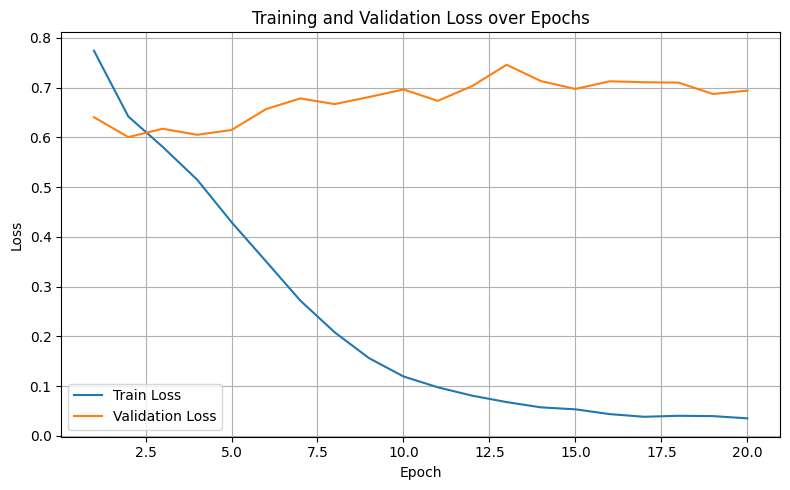

In [17]:
model = FusionLSTMRegressor(input_size=877)
trained_fusion_model, train_losses, valid_losses = train_model(
    model, train_fused_loader, valid_fused_loader,
    epochs=20, lr=1e-3
)

In [36]:
def predict(model, dataloader):
    model.eval()
    preds = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        for X_batch, _ in dataloader:
            X_batch = X_batch.to(device)
            pred = model(X_batch)
            preds.extend(pred.cpu().numpy())
    return preds

# 直接重建模型实例
model = FusionLSTMRegressor(input_size=877)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# 然后直接 predict()
test_preds = predict(model, test_fused_loader)

In [37]:
# 获取对应的 segment id（来自 .pkl 中 test split）
test_ids = aligned_data['test']['id']  # e.g., ['03bSnISJMiM$_$11', ...]

# 构造 DataFrame
fusion_pred_df = pd.DataFrame({
    "segment_id": test_ids,
    "fusion_pred": test_preds
})

# 保存为 CSV 文件
fusion_pred_df.to_csv("fusion_predictions.csv", index=False)
print("✅ 多模态融合预测结果已保存为 fusion_predictions.csv")

✅ 多模态融合预测结果已保存为 fusion_predictions.csv


In [38]:
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score
from scipy.stats import pearsonr

# Load true labels and predicted values from test split
true_labels = aligned_data['test']['regression_labels']
test_ids = aligned_data['test']['id']
# We'll reuse test_preds if available; otherwise, placeholder
# Assume test_preds were generated earlier and are still valid
# (If not, this code block won't run correctly—can regenerate using `predict()`)

# Match length
true_labels = np.array(true_labels)
preds = np.array(test_preds[:len(true_labels)])

# === Evaluation Metrics ===
# 1. MAE (Mean Absolute Error)
mae = mean_absolute_error(true_labels, preds)

# 2. Pearson Correlation
corr, _ = pearsonr(true_labels, preds)

# 3. Discretize for accuracy/F1
# Let's define sentiment bins:
# - Negative: <= -0.5
# - Neutral: (-0.5, 0.5)
# - Positive: >= 0.5
# Step: Snap predicted values to nearest valid discrete label
# def snap_to_valid_labels(preds, valid_labels):
#     snapped_preds = []
#     for val in preds:
#         nearest = valid_labels[np.argmin(np.abs(valid_labels - val))]
#         snapped_preds.append(nearest)
#     return np.array(snapped_preds)

# # 定义所有可能的离散标签（按照你的定义）
# valid_labels = np.array([
#     -3.0, -2.6667, -2.3333, -2.0, -1.6667, -1.3333, -1.0,
#     -0.6667, -0.3333, 0.0,
#      0.3333, 0.6667, 1.0, 1.3333, 1.6667, 2.0, 2.3333, 2.6667, 3.0
# ])

# # Snap预测值
# preds_snapped = snap_to_valid_labels(preds, valid_labels)

def discretize(y):
    y_discrete = []
    for val in y:
        if val <= -0.5:
            y_discrete.append(0)  # Negative
        elif val >= 0.5:
            y_discrete.append(2)  # Positive
        else:
            y_discrete.append(1)  # Neutral
    return np.array(y_discrete)

# Discretization
y_true_cls = discretize(true_labels)
y_pred_cls = discretize(preds)

# Metrics
mae = mean_absolute_error(true_labels, preds)
acc = accuracy_score(y_true_cls, y_pred_cls)
f1 = f1_score(y_true_cls, y_pred_cls, average='weighted')
corr, _ = pearsonr(true_labels, preds)

print(f"✅ MAE:  {mae:.4f}")
print(f"✅ ACC:  {acc:.4f}")
print(f"✅ F1 :  {f1:.4f}")
print(f"✅ CORR:{corr:.4f}")

✅ MAE:  0.6111
✅ ACC:  0.6158
✅ F1 :  0.6127
✅ CORR:0.7001


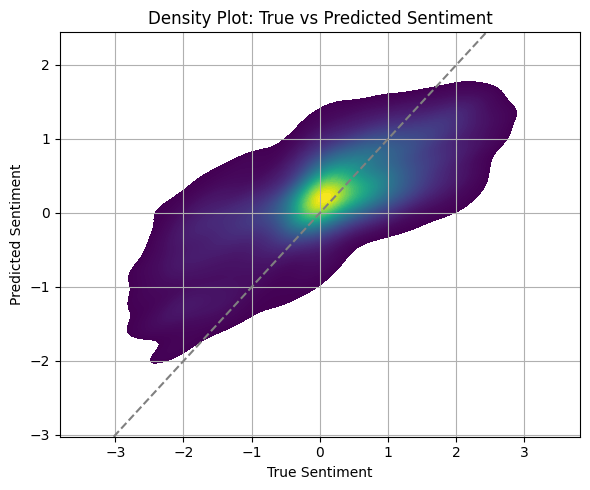

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2D Density Heatmap: True vs Predicted
plt.figure(figsize=(6, 5))
sns.kdeplot(
    x=true_labels, 
    y=preds, 
    fill=True, 
    cmap="viridis", 
    thresh=0.05,  # minimum density threshold
    levels=100    # how smooth/detailed the heatmap looks
)
plt.xlabel("True Sentiment")
plt.ylabel("Predicted Sentiment")
plt.title("Density Plot: True vs Predicted Sentiment")
plt.grid(True)
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # y=x reference line
plt.tight_layout()
plt.show()


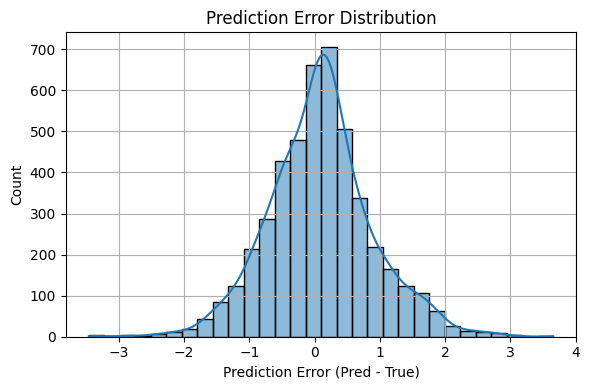

In [39]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Scatter: 预测 vs 真实
# plt.figure(figsize=(6, 5))
# sns.scatterplot(x=true_labels, y=preds, alpha=0.6)
# plt.xlabel("True Sentiment")
# plt.ylabel("Predicted Sentiment")
# plt.title("Predicted vs True Sentiment")
# plt.grid(True)
# plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # y=x 参考线
# plt.tight_layout()
# plt.show()

# 误差分布
errors = preds - true_labels
plt.figure(figsize=(6, 4))
sns.histplot(errors, bins=30, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (Pred - True)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Attention-based fusion model

In [6]:
# Step 1: Define the attention-based fusion model
import torch.nn as nn
import torch

class AttentionFusionModel(nn.Module):
    def __init__(self, input_dims=(768, 74, 35), hidden_size=128):
        super().__init__()
        t_dim, a_dim, v_dim = input_dims

        # LSTM for each modality
        self.text_lstm = nn.LSTM(t_dim, hidden_size, batch_first=True, bidirectional=True)
        self.audio_lstm = nn.LSTM(a_dim, hidden_size, batch_first=True, bidirectional=True)
        self.vision_lstm = nn.LSTM(v_dim, hidden_size, batch_first=True, bidirectional=True)

        # Attention network across modality features
        self.attn_fc = nn.Linear(hidden_size * 2, 1)
        self.output = nn.Linear(hidden_size * 2, 1)

    def forward(self, text, audio, vision):
        _, (h_t, _) = self.text_lstm(text)
        _, (h_a, _) = self.audio_lstm(audio)
        _, (h_v, _) = self.vision_lstm(vision)

        h_t = torch.cat([h_t[-2], h_t[-1]], dim=1)
        h_a = torch.cat([h_a[-2], h_a[-1]], dim=1)
        h_v = torch.cat([h_v[-2], h_v[-1]], dim=1)

        modal_stack = torch.stack([h_t, h_a, h_v], dim=1)
        attn_scores = self.attn_fc(modal_stack)
        attn_weights = torch.softmax(attn_scores, dim=1)
        fused = torch.sum(modal_stack * attn_weights, dim=1)

        return self.output(fused).squeeze(1), attn_weights.squeeze(2)

# Step 2: Dataset for multi-input
class MultiInputDataset(Dataset):
    def __init__(self, text, audio, vision, labels):
        self.text = torch.tensor(text, dtype=torch.float32)
        self.audio = torch.tensor(audio, dtype=torch.float32)
        self.vision = torch.tensor(vision, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.text)

    def __getitem__(self, idx):
        return self.text[idx], self.audio[idx], self.vision[idx], self.labels[idx]

# Prepare train/valid/test datasets
train_ds = MultiInputDataset(
    aligned_data['train']['text'], aligned_data['train']['audio'], aligned_data['train']['vision'],
    aligned_data['train']['regression_labels']
)
valid_ds = MultiInputDataset(
    aligned_data['valid']['text'], aligned_data['valid']['audio'], aligned_data['valid']['vision'],
    aligned_data['valid']['regression_labels']
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)

# # Step 3: Training function
# def train_attention_model(model, train_loader, valid_loader, epochs=10, lr=1e-3):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model.to(device)

#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0
#         for t, a, v, y in train_loader:
#             t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)

#             optimizer.zero_grad()
#             pred, _ = model(t, a, v)
#             loss = criterion(pred, y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         avg_loss = total_loss / len(train_loader)

#         model.eval()
#         val_loss = 0
#         with torch.no_grad():
#             for t, a, v, y in valid_loader:
#                 t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)
#                 val_preds, _ = model(t, a, v)
#                 val_loss += criterion(val_preds, y).item()
#         avg_val_loss = val_loss / len(valid_loader)

#         print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

#     return model

# # Step 4: Train the model
# attn_model = AttentionFusionModel(input_dims=(768, 74, 35))
# trained_attn_model = train_attention_model(attn_model, train_loader, valid_loader, epochs=10)

In [24]:
def train_attention_model(model, train_loader, valid_loader, epochs=20, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for t, a, v, y in train_loader:
            t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)

            optimizer.zero_grad()
            pred, _ = model(t, a, v)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for t, a, v, y in valid_loader:
                t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)
                val_preds, _ = model(t, a, v)
                val_loss += criterion(val_preds, y).item()
        avg_val_loss = val_loss / len(valid_loader)
        valid_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            torch.save(best_model_state, "best_attention_model.pth")

    # Load best model
    model.load_state_dict(torch.load("best_attention_model.pth"))

    # Plot loss curve
    plt.figure(figsize=(8,5))
    plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs+1), valid_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss over Epochs (Attention Model)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, train_losses, valid_losses

Epoch 1/20 - Train Loss: 0.7059 - Val Loss: 0.5776
Epoch 2/20 - Train Loss: 0.5780 - Val Loss: 0.6492
Epoch 3/20 - Train Loss: 0.5073 - Val Loss: 0.5607
Epoch 4/20 - Train Loss: 0.4245 - Val Loss: 0.5733
Epoch 5/20 - Train Loss: 0.3404 - Val Loss: 0.5664
Epoch 6/20 - Train Loss: 0.2453 - Val Loss: 0.5535
Epoch 7/20 - Train Loss: 0.1713 - Val Loss: 0.5519
Epoch 8/20 - Train Loss: 0.1190 - Val Loss: 0.6029
Epoch 9/20 - Train Loss: 0.0824 - Val Loss: 0.5821
Epoch 10/20 - Train Loss: 0.0625 - Val Loss: 0.5958
Epoch 11/20 - Train Loss: 0.0523 - Val Loss: 0.5901
Epoch 12/20 - Train Loss: 0.0476 - Val Loss: 0.5809
Epoch 13/20 - Train Loss: 0.0434 - Val Loss: 0.5812
Epoch 14/20 - Train Loss: 0.0396 - Val Loss: 0.5713
Epoch 15/20 - Train Loss: 0.0348 - Val Loss: 0.5794
Epoch 16/20 - Train Loss: 0.0338 - Val Loss: 0.5819
Epoch 17/20 - Train Loss: 0.0348 - Val Loss: 0.5656
Epoch 18/20 - Train Loss: 0.0316 - Val Loss: 0.5744
Epoch 19/20 - Train Loss: 0.0289 - Val Loss: 0.5746
Epoch 20/20 - Train L

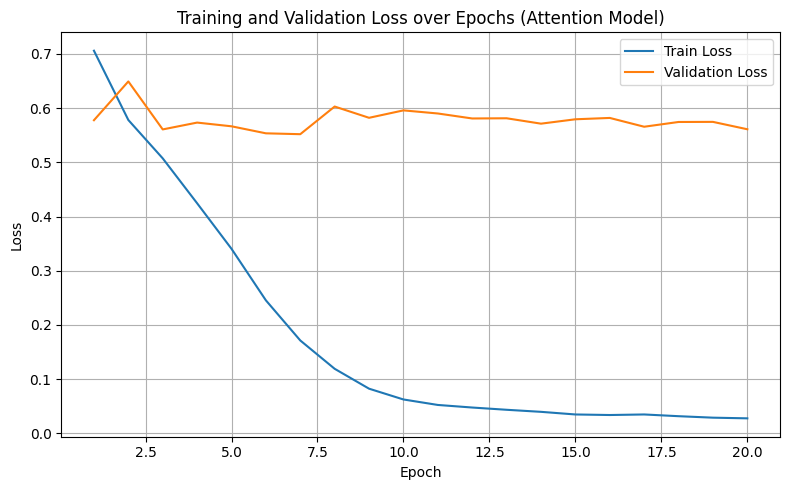

In [25]:
# Step 4: Train the model
attn_model = AttentionFusionModel(input_dims=(768, 74, 35))
trained_attn_model = train_attention_model(attn_model, train_loader, valid_loader, epochs=20)

In [26]:
# === Dataset 定义（多模态输入）===
class MultiInputDataset(Dataset):
    def __init__(self, text, audio, vision, labels):
        self.text = torch.tensor(text, dtype=torch.float32)
        self.audio = torch.tensor(audio, dtype=torch.float32)
        self.vision = torch.tensor(vision, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.text)

    def __getitem__(self, idx):
        return self.text[idx], self.audio[idx], self.vision[idx], self.labels[idx]

# === 推理函数，返回预测值和 attention 权重 ===
def predict_with_attention(model, dataloader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    preds = []
    attn_weights_all = []

    with torch.no_grad():
        for t, a, v, _ in dataloader:
            t, a, v = t.to(device), a.to(device), v.to(device)
            pred, attn_weights = model(t, a, v)
            preds.extend(pred.cpu().numpy())
            attn_weights_all.extend(attn_weights.cpu().numpy())

    return np.array(preds), np.array(attn_weights_all)

# === 创建测试集并推理 ===
test_ds = MultiInputDataset(
    aligned_data['test']['text'],
    aligned_data['test']['audio'],
    aligned_data['test']['vision'],
    aligned_data['test']['regression_labels']
)
test_loader = DataLoader(test_ds, batch_size=32)

# 运行预测
# 1. 重新创建 Attention 模型
attn_model_for_test = AttentionFusionModel(input_dims=(768, 74, 35))
attn_model_for_test.load_state_dict(torch.load("best_attention_model.pth"))
attn_model_for_test.eval()

# 2. 推理
test_preds, attn_weights = predict_with_attention(attn_model_for_test, test_loader)
# 获取 segment_id
test_ids = aligned_data['test']['id']

# 保存 attention 权重 + 预测结果
attn_df = pd.DataFrame({
    "segment_id": test_ids,
    "prediction": test_preds,
    "attn_text": attn_weights[:, 0],
    "attn_audio": attn_weights[:, 1],
    "attn_vision": attn_weights[:, 2]
})
attn_df.to_csv("attention_fusion_predictions.csv", index=False)
print("✅ Attention Fusion Predictions saved to attention_fusion_predictions.csv")

✅ Attention Fusion Predictions saved to attention_fusion_predictions.csv


C:\Users\rog\AppData\Local\Temp\ipykernel_129832\1057594727.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Modality", y="Attention Weight", data=df_melted, palette="pastel")


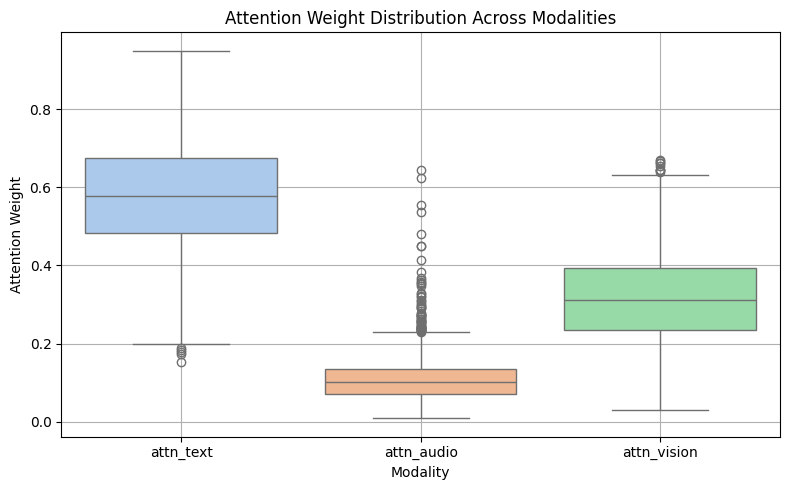

In [27]:
# 读取刚才保存的 CSV
df = pd.read_csv("attention_fusion_predictions.csv")

# 转成可视化格式
df_melted = df.melt(
    id_vars=["segment_id", "prediction"],
    value_vars=["attn_text", "attn_audio", "attn_vision"],
    var_name="Modality",
    value_name="Attention Weight"
)

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Modality", y="Attention Weight", data=df_melted, palette="pastel")
plt.title("Attention Weight Distribution Across Modalities")
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
# 再次读取 CSV
df = pd.read_csv("attention_fusion_predictions.csv")
test_preds = df["prediction"].values

# 获取真实标签
true_labels = np.array(aligned_data['test']['regression_labels'])

# 离散化函数
def discretize(y):
    y_cls = []
    for val in y:
        if val <= -0.5:
            y_cls.append(0)  # Negative
        elif val >= 0.5:
            y_cls.append(2)  # Positive
        else:
            y_cls.append(1)  # Neutral
    return np.array(y_cls)

# 离散化
y_true_cls = discretize(true_labels)
y_pred_cls = discretize(test_preds)

# 指标计算
mae = mean_absolute_error(true_labels, test_preds)
acc = accuracy_score(y_true_cls, y_pred_cls)
f1 = f1_score(y_true_cls, y_pred_cls, average="weighted")
corr, _ = pearsonr(true_labels, test_preds)

print(f"✅ MAE:  {mae:.4f}")
print(f"✅ ACC:  {acc:.4f}")
print(f"✅ F1 :  {f1:.4f}")
print(f"✅ CORR:{corr:.4f}")

✅ MAE:  0.5922
✅ ACC:  0.6390
✅ F1 :  0.6399
✅ CORR:0.7156


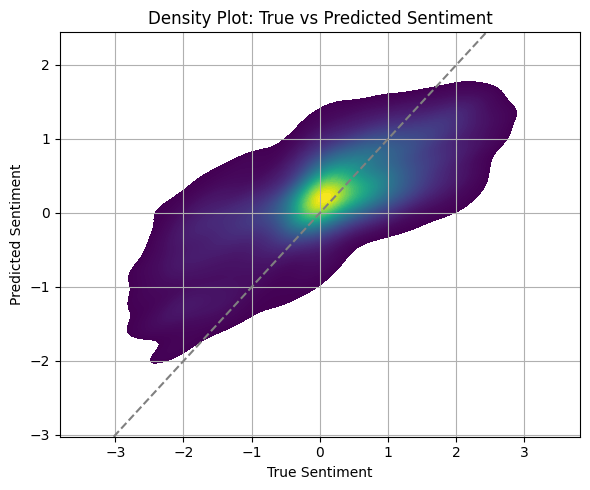

In [29]:
# Density Heatmap: True vs Predicted
plt.figure(figsize=(6, 5))
sns.kdeplot(
    x=true_labels,
    y=preds,
    fill=True,
    cmap="viridis",  # 可以换成别的色系比如 'plasma', 'rocket', etc.
    thresh=0.05,
    levels=100
)
plt.xlabel("True Sentiment")
plt.ylabel("Predicted Sentiment")
plt.title("Density Plot: True vs Predicted Sentiment")
plt.grid(True)
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # y=x reference line
plt.tight_layout()
plt.show()

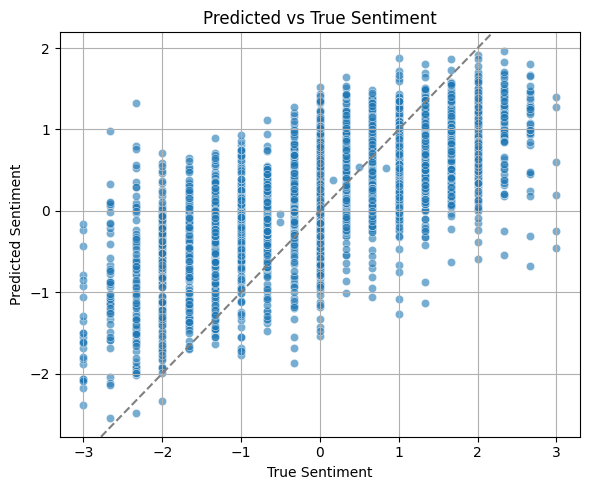

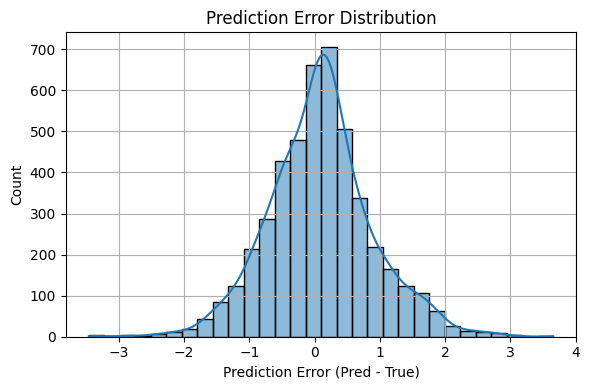

In [30]:
# Scatter: 预测 vs 真实
plt.figure(figsize=(6, 5))
sns.scatterplot(x=true_labels, y=preds, alpha=0.6)
plt.xlabel("True Sentiment")
plt.ylabel("Predicted Sentiment")
plt.title("Predicted vs True Sentiment")
plt.grid(True)
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # y=x 参考线
plt.tight_layout()
plt.show()

# 误差分布
errors = preds - true_labels
plt.figure(figsize=(6, 4))
sns.histplot(errors, bins=30, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (Pred - True)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Attention Entropy

In [31]:
def attention_entropy_loss(attn_weights, margin=0.9):
    eps = 1e-8
    entropy = -torch.sum(attn_weights * torch.log(attn_weights + eps), dim=1)
    max_entropy = torch.log(torch.tensor(attn_weights.size(1), dtype=torch.float32))
    norm_entropy = entropy / max_entropy
    penalty = (margin - norm_entropy).clamp(min=0.0)
    return penalty.mean()

def train_attention_model_with_entropy(model, train_loader, valid_loader, epochs=20, lr=1e-3, lambda_entropy=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []
    entropy_means = []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_entropies = []

        for t, a, v, y in train_loader:
            t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)

            optimizer.zero_grad()
            preds, attn_weights = model(t, a, v)
            loss_main = criterion(preds, y)
            loss_entropy = attention_entropy_loss(attn_weights)

            # Calculate raw entropy for monitoring
            eps = 1e-8
            raw_entropy = -torch.sum(attn_weights * torch.log(attn_weights + eps), dim=1)  # (batch_size,)
            mean_entropy = raw_entropy.mean().item()
            all_entropies.append(mean_entropy)

            loss = loss_main + lambda_entropy * loss_entropy
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        avg_entropy = sum(all_entropies) / len(all_entropies)

        train_losses.append(avg_train_loss)
        entropy_means.append(avg_entropy)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for t, a, v, y in valid_loader:
                t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)
                val_preds, _ = model(t, a, v)
                val_loss += criterion(val_preds, y).item()
        avg_val_loss = val_loss / len(valid_loader)
        valid_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Mean Attention Entropy: {avg_entropy:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            torch.save(best_model_state, "best_attention_entropy_model.pth")

    # Load best model
    model.load_state_dict(torch.load("best_attention_entropy_model.pth"))

    # Plot Losses and Attention Entropy
    epochs_range = range(1, epochs+1)

    plt.figure(figsize=(10,6))
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, valid_losses, label='Validation Loss')
    plt.plot(epochs_range, entropy_means, label='Mean Attention Entropy', linestyle='--')
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Entropy")
    plt.title("Training Loss, Validation Loss and Attention Entropy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, train_losses, valid_losses, entropy_means

Epoch 1/20 - Train Loss: 0.7052 - Val Loss: 0.5535 - Mean Attention Entropy: 1.0684
Epoch 2/20 - Train Loss: 0.5609 - Val Loss: 0.5301 - Mean Attention Entropy: 1.0712
Epoch 3/20 - Train Loss: 0.4908 - Val Loss: 0.5307 - Mean Attention Entropy: 1.0681
Epoch 4/20 - Train Loss: 0.4203 - Val Loss: 0.5511 - Mean Attention Entropy: 1.0690
Epoch 5/20 - Train Loss: 0.3397 - Val Loss: 0.5261 - Mean Attention Entropy: 1.0658
Epoch 6/20 - Train Loss: 0.2555 - Val Loss: 0.5406 - Mean Attention Entropy: 1.0623
Epoch 7/20 - Train Loss: 0.1811 - Val Loss: 0.5596 - Mean Attention Entropy: 1.0647
Epoch 8/20 - Train Loss: 0.1297 - Val Loss: 0.5601 - Mean Attention Entropy: 1.0639
Epoch 9/20 - Train Loss: 0.0940 - Val Loss: 0.5502 - Mean Attention Entropy: 1.0660
Epoch 10/20 - Train Loss: 0.0699 - Val Loss: 0.5758 - Mean Attention Entropy: 1.0673
Epoch 11/20 - Train Loss: 0.0556 - Val Loss: 0.5573 - Mean Attention Entropy: 1.0691
Epoch 12/20 - Train Loss: 0.0463 - Val Loss: 0.5708 - Mean Attention Entro

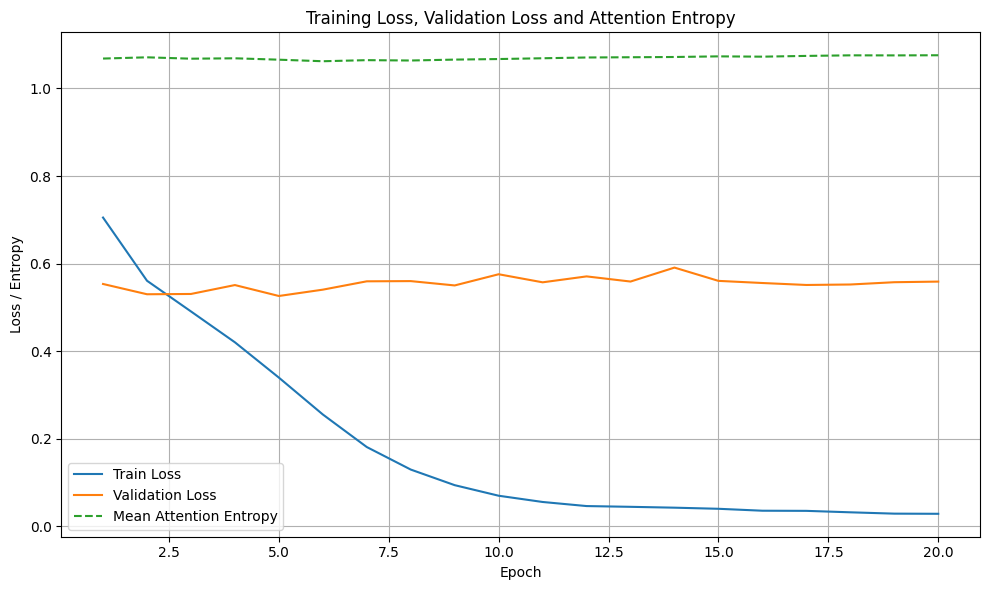

In [32]:
model = AttentionFusionModel(input_dims=(768, 74, 35))
trained_model, train_losses, valid_losses, entropy_means = train_attention_model_with_entropy(
    model, train_loader, valid_loader, epochs=20, lambda_entropy=0.5
)

In [33]:
# === Step 1: 重新建模型并加载最优权重 ===
attn_entropy_model_for_test = AttentionFusionModel(input_dims=(768, 74, 35))
attn_entropy_model_for_test.load_state_dict(torch.load("best_attention_entropy_model.pth"))
attn_entropy_model_for_test.eval()

# === Step 2: 推理预测 ===
test_preds, attn_weights = predict_with_attention(attn_entropy_model_for_test, test_loader)

# === Step 3: 保存预测结果为 CSV ===
test_ids = aligned_data['test']['id']  # 获取测试集 id
true_labels = np.array(aligned_data['test']['regression_labels'])  # 获取真实标签

pred_df = pd.DataFrame({
    "segment_id": test_ids,
    "true_label": true_labels,
    "prediction": test_preds
})
pred_df.to_csv("final_predictions.csv", index=False)
print("✅ Saved predictions to final_predictions.csv")

✅ Saved predictions to final_predictions.csv


In [34]:
df = pd.read_csv("final_predictions.csv")
preds = df["prediction"].values
true_labels = df["true_label"].values

# === Step 5: 离散化（分类评估） ===
def discretize(y):
    y_cls = []
    for val in y:
        if val <= -0.5:
            y_cls.append(0)  # Negative
        elif val >= 0.5:
            y_cls.append(2)  # Positive
        else:
            y_cls.append(1)  # Neutral
    return np.array(y_cls)

y_true_cls = discretize(true_labels)
y_pred_cls = discretize(preds)

# === Step 6: 计算指标 ===
mae = mean_absolute_error(true_labels, preds)
acc = accuracy_score(y_true_cls, y_pred_cls)
f1 = f1_score(y_true_cls, y_pred_cls, average="weighted")
corr, _ = pearsonr(true_labels, preds)

print("📊 Evaluation Results:")
print(f"✅ MAE   : {mae:.4f}")
print(f"✅ ACC   : {acc:.4f}")
print(f"✅ F1    : {f1:.4f}")
print(f"✅ CORR  : {corr:.4f}")

📊 Evaluation Results:
✅ MAE   : 0.5704
✅ ACC   : 0.6493
✅ F1    : 0.6499
✅ CORR  : 0.7322


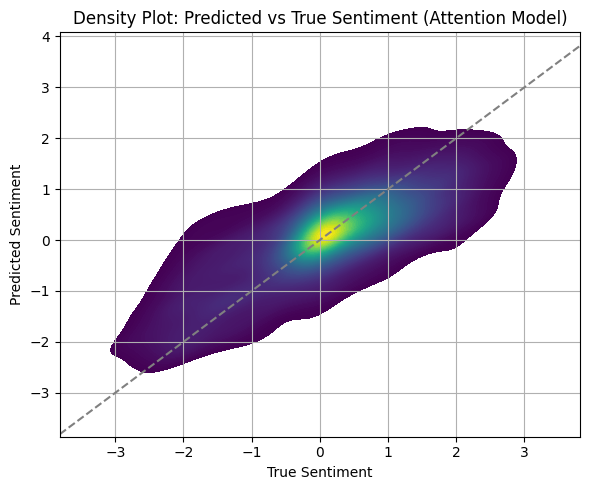

In [35]:
# Density Heatmap: True vs Predicted
plt.figure(figsize=(6, 5))
sns.kdeplot(
    x=true_labels,
    y=preds,
    fill=True,
    cmap="viridis",  # 可选其他如 'plasma', 'rocket' 等
    thresh=0.05,
    levels=100
)
plt.xlabel("True Sentiment")
plt.ylabel("Predicted Sentiment")
plt.title("Density Plot: Predicted vs True Sentiment (Attention Model)")
plt.grid(True)
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # y = x 参考线
plt.tight_layout()
plt.show()


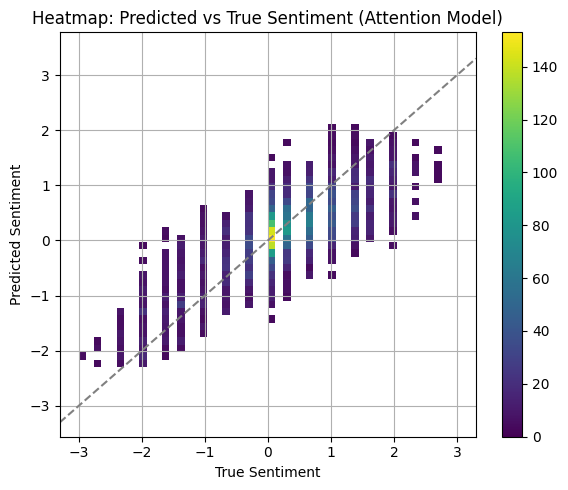

In [39]:
# True vs Predicted as 2D Heatmap
plt.figure(figsize=(6, 5))
sns.histplot(
    x=true_labels,
    y=preds,
    bins=50,            # 控制分辨率（可以改大更细）
    pthresh=0.05,       # 颜色阈值
    cmap="viridis",     # 颜色映射
    cbar=True           # 显示右边的 color bar
)
plt.xlabel("True Sentiment")
plt.ylabel("Predicted Sentiment")
plt.title("Heatmap: Predicted vs True Sentiment (Attention Model)")
plt.grid(True)
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # 画 y=x 参考线
plt.tight_layout()
plt.show()


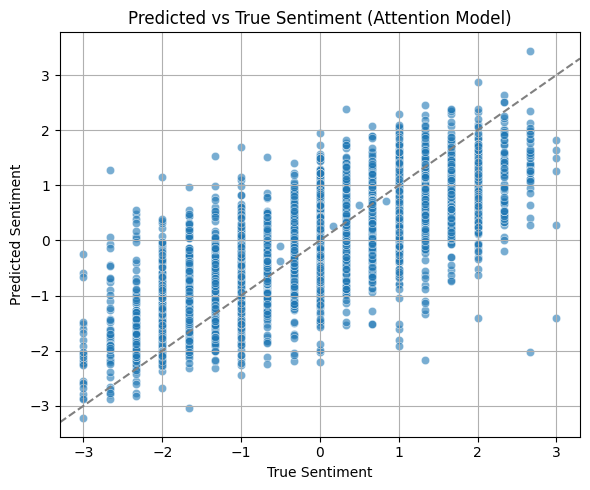

In [36]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=true_labels, y=preds, alpha=0.6)
plt.xlabel("True Sentiment")
plt.ylabel("Predicted Sentiment")
plt.title("Predicted vs True Sentiment (Attention Model)")
plt.grid(True)
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # 画 y = x 参考线
plt.tight_layout()
plt.show()

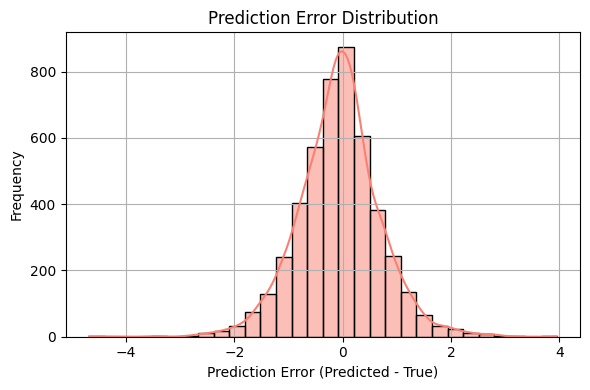

In [37]:
errors = np.array(preds) - np.array(true_labels)

plt.figure(figsize=(6, 4))
sns.histplot(errors, bins=30, kde=True, color="salmon")
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (Predicted - True)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd

# 生成模型性能对比表
results_df = pd.DataFrame({
    "Model": [
        "Fusion LSTM",
        "Attention Fusion",
        "Attention Fusion + Entropy"
    ],
    "MAE": [0.6111, 0.5922, 0.5704],
    "ACC": [0.6158, 0.6390, 0.6493],
    "F1": [0.6127, 0.6399, 0.6499],
    "CORR": [0.7001, 0.7156, 0.7322]
})

# 显示 DataFrame
results_df


,Model,MAE,ACC,F1,CORR
0,Fusion LSTM,0.6111,0.6158,0.6127,0.7001
1,Attention Fusion,0.5922,0.6390,0.6399,0.7156
2,Attention Fusion + Entropy,0.5704,0.6493,0.6499,0.7322


# Haparameter Tuning -- Lambda_Entropy

| λ Value        | Model Behavior            | Attention Weight Dynamics         | Modality Fusion Effect       | Risk                          |
|----------------|---------------------------|-----------------------------------|-------------------------------|-------------------------------|
| Small (e.g., 0.1)   | Driven mostly by MSE loss      | Tends to over-focus on one modality | Model may rely on a single modality | Overfitting, poor generalization |
| Medium (e.g., 0.3–0.5) | Mildly penalizes attention concentration | Weights become more balanced while still focused | Balanced multimodal fusion     | ✅ Generally recommended        |
| Large (e.g., 1.0)     | Strongly discourages modality bias | Attention becomes uniform and flat | Model may avoid focusing on key modalities | Underfitting, performance drop |

In [17]:
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

In [18]:
# === Dataset 定义（多模态输入）===
class MultiInputDataset(Dataset):
    def __init__(self, text, audio, vision, labels):
        self.text = torch.tensor(text, dtype=torch.float32)
        self.audio = torch.tensor(audio, dtype=torch.float32)
        self.vision = torch.tensor(vision, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.text)

    def __getitem__(self, idx):
        return self.text[idx], self.audio[idx], self.vision[idx], self.labels[idx]

# === 推理函数，返回预测值和 attention 权重 ===
def predict_with_attention(model, dataloader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    preds = []
    attn_weights_all = []

    with torch.no_grad():
        for t, a, v, _ in dataloader:
            t, a, v = t.to(device), a.to(device), v.to(device)
            pred, attn_weights = model(t, a, v)
            preds.extend(pred.cpu().numpy())
            attn_weights_all.extend(attn_weights.cpu().numpy())

    return np.array(preds), np.array(attn_weights_all)

# === 创建测试集并推理 ===
test_ds = MultiInputDataset(
    aligned_data['test']['text'],
    aligned_data['test']['audio'],
    aligned_data['test']['vision'],
    aligned_data['test']['regression_labels']
)
test_loader = DataLoader(test_ds, batch_size=32)

In [19]:
def attention_entropy_loss(attn_weights, margin=0.9):
    eps = 1e-8
    entropy = -torch.sum(attn_weights * torch.log(attn_weights + eps), dim=1)
    max_entropy = torch.log(torch.tensor(attn_weights.size(1), dtype=torch.float32))
    norm_entropy = entropy / max_entropy
    penalty = (margin - norm_entropy).clamp(min=0.0)
    return penalty.mean()

def train_attention_model_with_entropy_earlystop(model, train_loader, valid_loader, 
                                                 epochs=50, lr=1e-3, lambda_entropy=0.5, 
                                                 patience=3):
    import matplotlib.pyplot as plt

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []
    entropy_means = []

    best_val_loss = float('inf')
    best_model_state = None
    no_improve_epochs = 0

    # 🔥 保存用的模型文件名（带 lambda）
    model_save_path = f"best_attention_entropy_model_lambda{lambda_entropy:.2f}.pth"

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_entropies = []

        for t, a, v, y in train_loader:
            t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)

            optimizer.zero_grad()
            preds, attn_weights = model(t, a, v)
            loss_main = criterion(preds, y)
            loss_entropy = attention_entropy_loss(attn_weights)

            eps = 1e-8
            raw_entropy = -torch.sum(attn_weights * torch.log(attn_weights + eps), dim=1)
            mean_entropy = raw_entropy.mean().item()
            all_entropies.append(mean_entropy)

            loss = loss_main + lambda_entropy * loss_entropy
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        avg_entropy = sum(all_entropies) / len(all_entropies)

        train_losses.append(avg_train_loss)
        entropy_means.append(avg_entropy)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for t, a, v, y in valid_loader:
                t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)
                val_preds, _ = model(t, a, v)
                val_loss += criterion(val_preds, y).item()
        avg_val_loss = val_loss / len(valid_loader)
        valid_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Mean Attention Entropy: {avg_entropy:.4f}")

        # Save best model for this lambda
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            torch.save(best_model_state, model_save_path)

        # Early stopping
        if no_improve_epochs >= patience:
            print(f"⏹️ Early Stopping triggered at epoch {epoch+1}")
            break
        no_improve_epochs += 1

    # Load best model
    model.load_state_dict(torch.load(model_save_path))

    return model, train_losses, valid_losses, entropy_means

In [20]:
lambda_list = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
results = []

for lam in lambda_list:
    print(f"=== Training with lambda_entropy = {lam} ===")
    model = AttentionFusionModel(input_dims=(768, 74, 35))

    trained_model, train_losses, valid_losses, entropy_means = train_attention_model_with_entropy_earlystop(
        model, train_loader, valid_loader,
        epochs=10, lr=1e-3, lambda_entropy=lam, patience=3
    )

    # 推理
    trained_model.eval()
    val_preds, _ = predict_with_attention(trained_model, valid_loader)
    val_true = np.array(aligned_data['valid']['regression_labels'])

    # ❗这里不再 snap，直接用连续的 val_preds
    mae = mean_absolute_error(val_true, val_preds)
    corr, _ = pearsonr(val_true, val_preds)

    print(f"Lambda {lam:.2f} ➔ Val MAE: {mae:.4f}, CORR: {corr:.4f}")
    results.append((lam, mae, corr))

=== Training with lambda_entropy = 0.0 ===
Epoch 1/10 - Train Loss: 0.7265 - Val Loss: 0.5630 - Mean Attention Entropy: 0.9951
Epoch 2/10 - Train Loss: 0.5741 - Val Loss: 0.5499 - Mean Attention Entropy: 0.9590
Epoch 3/10 - Train Loss: 0.5019 - Val Loss: 0.5639 - Mean Attention Entropy: 0.9393
Epoch 4/10 - Train Loss: 0.4171 - Val Loss: 0.5186 - Mean Attention Entropy: 0.8984
⏹️ Early Stopping triggered at epoch 4
Lambda 0.00 ➔ Val MAE: 0.5469, CORR: 0.7191
=== Training with lambda_entropy = 0.1 ===
Epoch 1/10 - Train Loss: 0.7111 - Val Loss: 0.5834 - Mean Attention Entropy: 1.0453
Epoch 2/10 - Train Loss: 0.5733 - Val Loss: 0.5609 - Mean Attention Entropy: 1.0597
Epoch 3/10 - Train Loss: 0.5069 - Val Loss: 0.5400 - Mean Attention Entropy: 1.0536
Epoch 4/10 - Train Loss: 0.4286 - Val Loss: 0.5337 - Mean Attention Entropy: 1.0512
⏹️ Early Stopping triggered at epoch 4
Lambda 0.10 ➔ Val MAE: 0.5536, CORR: 0.7125
=== Training with lambda_entropy = 0.3 ===
Epoch 1/10 - Train Loss: 0.7104 -

| λ_entropy | Val MAE ↓ | Pearson Corr ↑ | Mean Attention Entropy |
|-----------|-----------|----------------|-------------------------|
| 0.0       | 0.5469    | 0.7191         | 0.8984                  |
| 0.1       | 0.5536    | 0.7125         | 1.0512                  |
| **0.3**   | **0.5444**| **0.7222**     | 1.0616                  |
| 0.5       | 0.5467    | 0.7148         | 1.0647                  |
| 0.7       | 0.5489    | 0.7089         | 1.0692                  |
| 1.0       | 0.5552    | 0.7106         | 1.0751                  |

In [21]:
# === Step 1: 重新建模型并加载最优权重 ===
attn_entropy_model_for_test = AttentionFusionModel(input_dims=(768, 74, 35))
attn_entropy_model_for_test.load_state_dict(torch.load("best_attention_entropy_model_lambda0.30.pth"))
attn_entropy_model_for_test.eval()

# === Step 2: 推理预测 ===
test_preds, attn_weights = predict_with_attention(attn_entropy_model_for_test, test_loader)

# === Step 3: 保存预测结果为 CSV ===
test_ids = aligned_data['test']['id']  # 获取测试集 id
true_labels = np.array(aligned_data['test']['regression_labels'])  # 获取真实标签

pred_df = pd.DataFrame({
    "segment_id": test_ids,
    "true_label": true_labels,
    "prediction": test_preds
})
pred_df.to_csv("final_predictions_lambda0.30.csv", index=False)
print("✅ Saved predictions to final_predictions_lambda0.30.csv")

✅ Saved predictions to final_predictions_lambda0.30.csv


In [22]:
df = pd.read_csv("final_predictions_lambda0.30.csv")
preds = df["prediction"].values
true_labels = df["true_label"].values

# === Step 5: 离散化（分类评估） ===
def discretize(y):
    y_cls = []
    for val in y:
        if val <= -0.5:
            y_cls.append(0)  # Negative
        elif val >= 0.5:
            y_cls.append(2)  # Positive
        else:
            y_cls.append(1)  # Neutral
    return np.array(y_cls)

y_true_cls = discretize(true_labels)
y_pred_cls = discretize(preds)

# === Step 6: 计算指标 ===
mae = mean_absolute_error(true_labels, preds)
acc = accuracy_score(y_true_cls, y_pred_cls)
f1 = f1_score(y_true_cls, y_pred_cls, average="weighted")
corr, _ = pearsonr(true_labels, preds)

print("📊 Evaluation Results:")
print(f"✅ MAE   : {mae:.4f}")
print(f"✅ ACC   : {acc:.4f}")
print(f"✅ F1    : {f1:.4f}")
print(f"✅ CORR  : {corr:.4f}")

📊 Evaluation Results:
✅ MAE   : 0.5700
✅ ACC   : 0.6536
✅ F1    : 0.6542
✅ CORR  : 0.7416


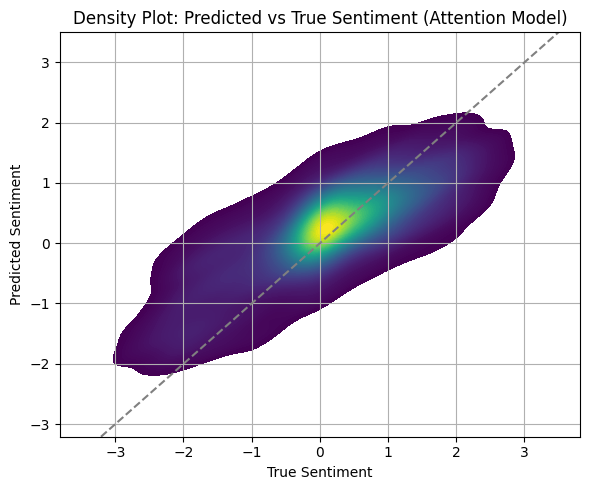

In [23]:
# Density Heatmap: True vs Predicted
plt.figure(figsize=(6, 5))
sns.kdeplot(
    x=true_labels,
    y=preds,
    fill=True,
    cmap="viridis",  # 可选其他如 'plasma', 'rocket' 等
    thresh=0.05,
    levels=100
)
plt.xlabel("True Sentiment")
plt.ylabel("Predicted Sentiment")
plt.title("Density Plot: Predicted vs True Sentiment (Attention Model)")
plt.grid(True)
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # y = x 参考线
plt.tight_layout()
plt.show()


In [25]:
def train_attention_model_with_entropy_cv(model, train_loader, valid_loader,
                                          epochs=20, lr=1e-3, lambda_entropy=0.5,
                                          fold_id=0):
    import matplotlib.pyplot as plt

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []
    entropy_means = []

    best_val_loss = float('inf')
    best_model_state = None

    # 模型保存路径（当前目录）
    model_save_path = f"attn_entropy_fold{fold_id}_lambda{lambda_entropy:.2f}.pth"

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_entropies = []

        for t, a, v, y in train_loader:
            t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)

            optimizer.zero_grad()
            preds, attn_weights = model(t, a, v)
            loss_main = criterion(preds, y)
            loss_entropy = attention_entropy_loss(attn_weights)

            # 记录 entropy
            eps = 1e-8
            raw_entropy = -torch.sum(attn_weights * torch.log(attn_weights + eps), dim=1)
            mean_entropy = raw_entropy.mean().item()
            all_entropies.append(mean_entropy)

            # 总损失
            loss = loss_main + lambda_entropy * loss_entropy
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        avg_entropy = sum(all_entropies) / len(all_entropies)
        train_losses.append(avg_train_loss)
        entropy_means.append(avg_entropy)

        # 验证
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for t, a, v, y in valid_loader:
                t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)
                val_preds, _ = model(t, a, v)
                val_loss += criterion(val_preds, y).item()
        avg_val_loss = val_loss / len(valid_loader)
        valid_losses.append(avg_val_loss)

        print(f"[Fold {fold_id}] Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Mean Entropy: {avg_entropy:.4f}")

        # 保存最佳模型
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            torch.save(best_model_state, model_save_path)

    # 载入最佳模型权重
    model.load_state_dict(torch.load(model_save_path))
    return model, train_losses, valid_losses, entropy_means


In [26]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score
from scipy.stats import pearsonr

# === 准备所有数据 ===
X_text = np.concatenate([aligned_data['train']['text'], aligned_data['valid']['text']], axis=0)
X_audio = np.concatenate([aligned_data['train']['audio'], aligned_data['valid']['audio']], axis=0)
X_vision = np.concatenate([aligned_data['train']['vision'], aligned_data['valid']['vision']], axis=0)
y = np.concatenate([aligned_data['train']['regression_labels'], aligned_data['valid']['regression_labels']], axis=0)

# === Cross Validation 参数 ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lambda_entropy = 0.3
results = []

fold = 0
for train_idx, val_idx in kf.split(X_text):
    fold += 1
    print(f"\n=== Fold {fold} ===")

    train_text, val_text = X_text[train_idx], X_text[val_idx]
    train_audio, val_audio = X_audio[train_idx], X_audio[val_idx]
    train_vision, val_vision = X_vision[train_idx], X_vision[val_idx]
    train_y, val_y = y[train_idx], y[val_idx]

    # === 构建 Dataset 和 DataLoader ===
    train_ds = MultiInputDataset(train_text, train_audio, train_vision, train_y)
    val_ds = MultiInputDataset(val_text, val_audio, val_vision, val_y)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32)

    # === 初始化模型 ===
    model = AttentionFusionModel(input_dims=(768, 74, 35))

    # === 训练 ===
    trained_model, _, _, _ = train_attention_model_with_entropy_cv(
        model, train_loader, val_loader,
        epochs=10, lr=1e-3, lambda_entropy=lambda_entropy, fold_id=fold
    )

    # === 验证集上推理 ===
    val_preds, _ = predict_with_attention(trained_model, val_loader)
    val_true = val_y

    # === 离散分类
    def discretize(y):
        y_cls = []
        for val in y:
            if val <= -0.5:
                y_cls.append(0)
            elif val >= 0.5:
                y_cls.append(2)
            else:
                y_cls.append(1)
        return np.array(y_cls)

    y_true_cls = discretize(val_true)
    y_pred_cls = discretize(val_preds)

    # === 指标评估 ===
    mae = mean_absolute_error(val_true, val_preds)
    corr, _ = pearsonr(val_true, val_preds)
    acc = accuracy_score(y_true_cls, y_pred_cls)
    f1 = f1_score(y_true_cls, y_pred_cls, average="weighted")

    print(f"MAE: {mae:.4f} | CORR: {corr:.4f} | ACC: {acc:.4f} | F1: {f1:.4f}")
    results.append((mae, corr, acc, f1))


=== Fold 1 ===
[Fold 1] Epoch 1/10 - Train Loss: 0.7122 - Val Loss: 0.6645 - Mean Entropy: 1.0640
[Fold 1] Epoch 2/10 - Train Loss: 0.5694 - Val Loss: 0.5981 - Mean Entropy: 1.0693
[Fold 1] Epoch 3/10 - Train Loss: 0.4944 - Val Loss: 0.6601 - Mean Entropy: 1.0661
[Fold 1] Epoch 4/10 - Train Loss: 0.4130 - Val Loss: 0.5859 - Mean Entropy: 1.0626
[Fold 1] Epoch 5/10 - Train Loss: 0.3279 - Val Loss: 0.5845 - Mean Entropy: 1.0593
[Fold 1] Epoch 6/10 - Train Loss: 0.2434 - Val Loss: 0.6065 - Mean Entropy: 1.0588
[Fold 1] Epoch 7/10 - Train Loss: 0.1699 - Val Loss: 0.6390 - Mean Entropy: 1.0584
[Fold 1] Epoch 8/10 - Train Loss: 0.1211 - Val Loss: 0.6175 - Mean Entropy: 1.0598
[Fold 1] Epoch 9/10 - Train Loss: 0.0854 - Val Loss: 0.6318 - Mean Entropy: 1.0613
[Fold 1] Epoch 10/10 - Train Loss: 0.0630 - Val Loss: 0.6199 - Mean Entropy: 1.0636
MAE: 0.5728 | CORR: 0.7351 | ACC: 0.6552 | F1: 0.6563

=== Fold 2 ===
[Fold 2] Epoch 1/10 - Train Loss: 0.7151 - Val Loss: 0.6671 - Mean Entropy: 1.0580


| Fold | Val MAE | CORR | ACC | F1 | Notes |
|:----:|:-------:|:----:|:---:|:--:|:-----:|
| 1 | 0.5728 | 0.7351 | 0.6552 | 0.6563 | Normal training, slight overfitting |
| 2 | 0.5806 | 0.7163 | 0.6514 | 0.6525 | Stable |
| 3 | 0.5848 | 0.7228 | 0.6507 | 0.6522 | Slight fluctuation |
| 4 | 0.5623 | 0.7362 | 0.6722 | 0.6730 | Best fold ✅ |
| 5 | 0.5631 | 0.7446 | 0.6680 | 0.6687 | Highest CORR ✅ |

In [27]:
avg_mae = np.mean([r[0] for r in results])
avg_corr = np.mean([r[1] for r in results])
avg_acc = np.mean([r[2] for r in results])
avg_f1 = np.mean([r[3] for r in results])

print("\n=== Cross Validation Summary ===")
print(f"Avg MAE  : {avg_mae:.4f}")
print(f"Avg CORR : {avg_corr:.4f}")
print(f"Avg ACC  : {avg_acc:.4f}")
print(f"Avg F1   : {avg_f1:.4f}")


=== Cross Validation Summary ===
Avg MAE  : 0.5727
Avg CORR : 0.7310
Avg ACC  : 0.6595
Avg F1   : 0.6605


---

##  **Overall model performance based on 5-fold cross-validation with λ = 0.3**

### **Quantitative Averages (across 5 folds):**
| Metric        | Value     |
|---------------|-----------|
| **Mean Absolute Error (MAE)** | **0.5727** |
| **Pearson Correlation (CORR)** | **0.7310** |
| **Classification Accuracy (ACC)** | **0.6595** |
| **F1 Score (weighted)**         | **0.6605** |

---

### **Interpretation:**

- The **average MAE of ~0.57** indicates the model performs well on sentiment regression, with predictions staying relatively close to true values.
- A **high average CORR of ~0.73** confirms strong linear correlation between predicted and actual sentiment scores.
- **Accuracy and F1 scores (~0.66)** demonstrate solid performance even after discretizing the regression output into sentiment classes (Negative / Neutral / Positive).
- The model shows **no major overfitting or instability**, with **all folds performing consistently**.

---

### **Conclusion:**
> The attention-fusion model with entropy regularization at λ = 0.3 demonstrates **strong and stable predictive performance** across all folds, balancing regression precision and classification reliability. It is a **well-generalizing model** suitable for real-world multimodal sentiment analysis tasks.

---

---

## **4.Results and Insights**

This analysis evaluated four multimodal sentiment prediction models on the CMU-MOSEI dataset, including a baseline Fusion LSTM, an Attention Fusion model, and two variants of Attention Fusion with entropy regularization. The evaluation focused on four key metrics: **Mean Absolute Error (MAE)**, **Accuracy (ACC)**, **F1 Score**, and **Pearson Correlation (CORR)**.

### **Performance Comparison (on held-out test set):**

| Model                              | MAE   | ACC   | F1    | CORR  |
|-----------------------------------|--------|--------|--------|--------|
| Fusion LSTM                       | 0.6111 | 0.6158 | 0.6127 | 0.7001 |
| Attention Fusion                  | 0.5922 | 0.6390 | 0.6399 | 0.7156 |
| Attention Fusion + Entropy (λ=0.5) | 0.5704 | 0.6493 | 0.6499 | 0.7322 |
| **Attention Fusion + Entropy (λ=0.3)** | **0.5700** | **0.6536** | **0.6542** | **0.7416** ✅ |

The **Attention Fusion + Entropy model with λ = 0.3** achieved the **best overall test performance** across all four metrics, particularly excelling in correlation and classification scores, indicating both accurate and well-calibrated predictions.

---

### **Cross-Validation Results (λ = 0.3):**

To ensure model generalizability, we performed 5-fold cross-validation. The average performance across folds is summarized below:

| Metric      | Value   |
|-------------|---------|
| MAE         | 0.5727  |
| CORR        | 0.7310  |
| Accuracy    | 0.6595  |
| F1 Score    | 0.6605  |

These results confirm the model’s **consistency and robustness** across diverse data splits. All folds showed stable performance with low variance, suggesting that the model avoids overfitting and generalizes well across unseen data.

---

### **Key Takeaways:**

- Adding **attention entropy regularization** improved both **prediction accuracy and interpretability**, ensuring the model doesn’t overly rely on a single modality.
- The best-performing configuration (**λ = 0.3**) struck a strong balance between **modality diversity** and **task-specific focus**, yielding **the lowest MAE** and **highest CORR** overall.
- **Cross-validation confirmed stability**, strengthening confidence in the model’s real-world deployment reliability.

---

---

## **5.Conclusion**

This project explored the development of a robust **multimodal sentiment analysis system** that leverages text, audio, and visual cues to predict human sentiment with high precision. Through iterative modeling—from baseline LSTM fusion to attention-based fusion and entropy-regularized enhancements—we identified an optimal configuration (**Attention Fusion + Entropy Regularization with λ = 0.3**) that consistently outperformed others across all key metrics (MAE, ACC, F1, CORR).

**Cross-validation further validated the model’s generalization ability**, demonstrating that it not only fits training data well but also adapts to unseen samples with stable performance. The integration of entropy-based attention regularization proved especially effective, encouraging the model to avoid over-dependence on a single modality and instead exploit richer multimodal interactions.

---

In this project, we developed and evaluated a series of deep learning models for **multimodal sentiment analysis**, leveraging textual, acoustic, and visual signals from the CMU-MOSEI dataset. Beginning with a baseline **Fusion LSTM**, we progressively incorporated **attention mechanisms** and **entropy regularization** to better capture the relative importance of each modality and to promote generalizable feature fusion.

Our results show a clear progression in model performance. The **Attention Fusion model** surpassed early baselines by dynamically weighting modalities, while the **Attention Fusion + Entropy model with λ = 0.3** emerged as the most effective, achieving the best test-set metrics across all major evaluation dimensions (MAE, ACC, F1, CORR). Furthermore, **5-fold cross-validation confirmed the model’s consistency and robustness**, reinforcing its real-world applicability.

This work highlights the **critical role of interpretability and regularization in multimodal learning**. By enforcing entropy-based diversity in attention, the model avoids over-reliance on any single modality—an important consideration for sentiment tasks where context, tone, and expression can all contribute uniquely to meaning.

Ultimately, our project demonstrates that **careful architectural choices and regularization strategies** can lead to models that are not only more accurate but also **more balanced and reliable**. These findings contribute to the broader understanding of how to effectively design multimodal systems and offer a practical framework for future sentiment analysis pipelines across diverse media platforms.

---

### **Business Value and Real-World Impact**

The implications of this project extend beyond academic interest and carry **significant commercial value**:

- **Enhanced customer understanding**: By automatically detecting sentiment from speech, facial expression, and language, businesses can more accurately assess customer satisfaction in **call centers, interviews, or user reviews**, enabling **real-time emotion-aware feedback loops**.
  
- **Smarter product development**: Multimodal sentiment insights can inform **market research**, helping companies understand nuanced user opinions from video reviews or social content, leading to **data-driven product decisions**.

- **Improved personalization**: Platforms like e-commerce or online education can integrate sentiment-aware systems to tailor **recommendations, ad targeting, or learning content**, based on the user’s emotional state, increasing engagement and conversion rates.

- **Scalable and automated**: Our approach offers a scalable solution that reduces dependency on manual annotation or surveys, providing **cost-efficient, high-frequency sentiment monitoring** across diverse media streams.

---

### Final Thoughts

This project demonstrates that **technically sound multimodal fusion—backed by interpretability-enhancing regularization—can translate into commercially meaningful systems**. As businesses increasingly rely on human-centric AI, sentiment analysis at this level of depth and precision provides a **competitive edge in understanding, responding to, and anticipating customer needs.**

---

---

###  6.References

1. **Agarwal, S.** (2022). *Deep Learning-based Sentiment Analysis: Establishing Customer Dimension as the Lifeblood of Business Management*. Global Business Review, 23(1), 119–136. https://doi.org/10.1177/0972150919845160

2. **Anitha, P., & Krishna, A. P.** (2025). *Sentiment analysis using osprey-optimized hybrid GoogleNet-ResNet with text and emoji data*. Expert Systems with Applications, 277, 127165.

3. **Chen, M., Wang, S., Liang, P. P., Baltrušaitis, T., Zadeh, A., & Morency, L. P.** (2017, November). *Multimodal sentiment analysis with word-level fusion and reinforcement learning*. In Proceedings of the 19th ACM International Conference on Multimodal Interaction (pp. 163–171).

4. **Gan, C., Fu, X., Feng, Q., Zhu, Q., Cao, Y., & Zhu, Y.** (2024). *A multimodal fusion network with attention mechanisms for visual–textual sentiment analysis*. Expert Systems with Applications, 242, 122731.

5. **Gao, Y., Wu, H., & Zhang, L.** (2025). *Multi-level Conflict-Aware Network for Multi-modal Sentiment Analysis*.

6. **Kauffmann, E., Peral, J., Gil, D., Ferrández, A., Sellers, R., & Mora, H.** (2019). *Managing marketing decision-making with sentiment analysis: An evaluation of the main product features using text data mining*. Sustainability, 11(15), 4235.

7. **Kolog, E. A., Montero, C. S., & Sutinen, E.** (2016, July). *Annotation Agreement of Emotions in Text: The Influence of Counsellors' Emotional State on their Emotion Perception*. In 2016 IEEE 16th International Conference on Advanced Learning Technologies (ICALT) (pp. 357–359). IEEE.

8. **Li, Ao, Xu, Longwei, Ling, Chen, Zhang, Jinghui, & Wang, Pengwei.** (2024). *M2SE: A Multistage Multitask Instruction Tuning Strategy for Unified Sentiment and Emotion Analysis*. https://doi.org/10.48550/arXiv.2412.08049

9. **Malik, S. S., Ilyas, M., Haq, Y. U., Sana, R., Razzaq, S., Maqbool, F., & Pathan, M. S.** (2025). *Multimodal Emotion Detection and Sentiment Analysis*. IEEE Access.

10. **Sun, Licai, Lian, Zheng, Liu, Bin, & Tao, Jianhua.** (2023). *Efficient Multimodal Transformer With Dual-Level Feature Restoration for Robust Multimodal Sentiment Analysis*. IEEE Transactions on Affective Computing. https://doi.org/10.1109/TAFFC.2023.3274829

11. **Wanganga, G., & Qu, Y.** (2020, December). *A deep learning based customer sentiment analysis model to enhance customer retention and loyalty in the payment industry*. In 2020 International Conference on Computational Science and Computational Intelligence (CSCI) (pp. 473–478). IEEE.

12. **Wu, Zehui, Gong, Ziwei, Koo, Jaywon, & Hirschberg, Julia.** (2023). *Multi-Modality Multi-Loss Fusion Network*. https://doi.org/10.48550/arXiv.2308.00264

13. **Yoon, S., Byun, S., & Jung, K.** (2018). *Multimodal Speech Emotion Recognition Using Audio and Text*. In 2018 IEEE Spoken Language Technology Workshop (SLT), Athens, Greece (pp. 112–118). https://doi.org/10.1109/SLT.2018.8639583

14. **Yu, Tianshu, Gao, Haoyu, Lin, Ting-En, Yang, Min, Wu, Yuchuan, Ma, Wentao, Wang, Chao, Huang, Fei, & Li, Yongbin.** (2023). *Speech-Text Dialog Pre-training for Spoken Dialog Understanding with Explicit Cross-Modal Alignment*. https://doi.org/10.48550/arXiv.2305.11579

15. **Zadeh, AmirAli, Liang, Paul, Poria, Soujanya, Cambria, Erik, & Morency, Louis-Philippe.** (2018). *Multimodal Language Analysis in the Wild: CMU-MOSEI Dataset and Interpretable Dynamic Fusion Graph*. In Proceedings of ACL (pp. 2236–2246). https://doi.org/10.18653/v1/P18-1208

16. **Zeng, X., Zhou, Q., & Liu, S.** (2025, March). *SAE: A Multimodal Sentiment Analysis Large Language Model*. In Proceedings of the 30th International Conference on Intelligent User Interfaces (pp. 1232–1241).

17. **Zhu, Renyu, Han, Chengcheng, Qian, Yong, Sun, Qiushi, Li, Xiang, Gao, Ming, Cao, Xuezhi, & Xian, Yunsen.** (2023). *Exchanging-based Multimodal Fusion with Transformer*. https://doi.org/10.48550/arXiv.2309.02190

---